<a href="https://colab.research.google.com/github/marianayanez31-ship-it/endometriosis_ML-model-/blob/main/MYD_Endometriosis_con_anotaciones_26ENE26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Construcción y validación de un modelo de Machine Learning basado en perfiles génicos de infiltración inmunitaria para la clasificación de tipos de endometriosis**
Autor: Mariana Yañez Díaz / Asesor: Dr. Ivan Salido / Fecha: 26 de enero de 2026



## **i. Preparación de matriz de expresión para los análisis de enriquecimiento celular y deconvolución (R)**

Para utilizar los programas bioinformáticos de xCell y MusiC2, necesitamos una matriz con las siguientes carácterísticas:
*   Elemento de lista
*   Elemento de lista

El siguiente procedimiento detalla los pasos a seguir para la generación y adaptación de esta matriz.

### **1. Instalación de librerías y paquetes**
---



In [ ]:
# 1.1 Instalación de Google Drive en tu entorno de trabajo
# Cuando se genera un código en Google colab, es recomendable la instalación de Google Drive directamente en el entorno de ejecución
# "Montar" tus carpetas de Google Drive se realiza por medio del entorno de ejecución Python.
# Una vez mondado Google Drive, puedes volver a cambiar a R
      #Referencia:https://sociedadesdigitales.org/web/2024/09/04/guia-para-el-manejo-de-google-colab/

from google.colab import drive
drive.mount('/content/drive')

KeyboardInterrupt: 

In [ ]:
# 1.2 Establecimiento del entorno de ejecución
#Averigua en qué carpeta estás trabajando
getwd()

# Establece la carpeta en la que deseas trabajar: setwd("ruta de acceso de la carpeta deseada")
setwd("G:/Mi unidad/MARIANA YAÑEZ DIAZ_INPER/TESIS")

# Confirma que la el nuevo "working directory ha sido implementado"
getwd()

In [ ]:
# 1.3 Instalación de librerías
# Librerías para el análisis y manejo de datos
install.packages("dplyr")
install.packages("tidyr")
install.packages("reshape")
install.packages("reshape2")
install.packages("R.utils")

# Librerías para el manejo y correcta instalación de otras paqueterías: Las librerías destinadas en este proyecto para las herramientas bioinformáticas (xCell  y MuSiC),
# requieren de otras liberías que soporten su correcta instalación desde repositorios de código como Bioconductor, CRAN y Github.
      #Referencias:
      #https://cran.r-project.org/web/packages/BiocManager/vignettes/BiocManager.html
      #https://www.bioconductor.org/install/
      #https://bioconductor.github.io/BiocManager/

if (!requireNamespace("BiocManager", quietly = TRUE))
  install.packages("BiocManager")
BiocManager::install(c("SingleCellExperiment", "Biobase", "TOAST"))
install.packages("devtools")

# Librerías para el ensayo de enriquecimiento celular (xCell) y deconvolución (MuSiC)
# Enriquecimiento celular (xCell)
devtools::install_github('dviraran/xCell', force = TRUE)

# Deconvolución(MuSiC)
# Un error común en la instalación de MuSiC fue instalar MuSiC como MuSiC2 al mismo tiempo, generando el siguiente error: Error in value[[3L]](cond): Package ‘MuSiC’ version 0.1.1 cannot be unloaded:
# Error in unloadNamespace(package) : namespace ‘MuSiC’ is imported by ‘MuSiC2’ so cannot be unloaded
# Para no generar este error es conveniente reiniciar la sesión de R y cargar solamente MuSiC o MuSiC2 de acuerdo a lo necesario
if (!requireNamespace("remotes", quietly = TRUE)) install.packages("remotes")
remotes::install_github("xuranw/MuSiC")

In [ ]:
# 1.4 Llamado de librerías
library(dplyr)
library(tidyr)
library(reshape)
library(reshape2)
library(SingleCellExperiment)
library(tidyverse)

library(xCell)

library(MuSiC)
exists("music2_prop_t_statistics")
#Para corroborar que el paquete music2_prop_t_statistics estácorrectamente cargado y no genere error se recomienda verificar que existe y es reconocido.

### **2. Cargado y manipulación de datos para la generación de la matriz de expresión**
---



In [ ]:
# 2.1 Cargar datos normalizados obtenidos a partir de microarreglos (normalización por cuantiles e implementado entre limmay rma y corregidos por efecto de lote usando Combat.)

# data_exprMat <- read.csv("ruta de acceso de tus datos normalizados")      #Ajustar el método de lectura de acuerdo al tipo de archivo que tengas
data_exprMat <- read.csv("ruta de acceso de GSE141549_normalizedcomb.csv")
class(data_exprMat)
head(data_exprMat)
str(data_exprMat)
dim(data_exprMat)

In [ ]:
# 2.2 Reorganización y limpieza de datos
# Es común en ensayos de microarreglos que diferentes sondas esten direccionadas a la misma region genica dentro de un mismo gen.
# Debido a esto, todos las sondas detectadas dan lugar a mediciones de nivel de expresion de ese gen, generando duplicados
# Para mitigar estos duplicados, se genera la siguiente evaluación:

# 2.2.1 Identificar si existen genes con mas de un valor de intensidad y cuantos son
print("No.Duplicated Genes")
table((duplicated(data_exprMat$Gene_symbol)))

sum(duplicated.data.frame("data_exprMat"),na.rm = FALSE)

In [ ]:
# 2.2.2 Idenfiticar el número de genes en la matriz de expresion
nrow(data_exprMat)

# 2.2.3 Identificar genes sin valores de expresion (NA)(Creación de una matriz con unicamente datos numéricos, dejando fuera los valores de texto como "NA")
data_expr_num <- data_exprMat[, !(colnames(data_exprMat) %in% c("Gene_symbol","Probe_Id"))] %>%
  mutate_if(is.factor, ~as.numeric(as.character(.)))

zero_exp_genes = rowSums(data_expr_num) > 0
data_expr_num = data_expr_num[zero_exp_genes, ]

dim(data_expr_num)

showDefault(zero_exp_genes)

In [ ]:
# 2.2.4 Formato lago: Colapsar los valores de expresion agrupandolos por gen (transformación de la matriz en un formato "largo", ordenada por el tipo de gen, repitiendose este las veces necesarias para cubir todas las muestras).
data_exprMat_merge = melt(data_exprMat)

# 2.2.5 Eliminación de genes repetidos (Esta función resume los valores de expresion asociados a un mismo gen obteniendo su porcentaje
coll_gen = data_exprMat_merge %>%
  group_by(Gene_symbol,variable)%>%summarise_all(max) %>%
  dplyr::mutate_if(is.numeric, format, 3)

dim(data_exprMat_merge)

# 2.2.6 Remover valores sin gen asociado
data_exprMat = data_exprMat[data_exprMat$Gene_symbol != "",]

In [ ]:
# 2.2.7 Obtener la matriz de valores de expresion agrupados por gen en formato "ancho"
exp_mat = dcast(coll_gen, Gene_symbol~variable, value.var = "value")

# 2.2.8 Asignar los valores de la columna "Gene_symbol" como nombre de filas "row_names", por lo que remueve la columna, "Gene_symbol"
rownames(exp_mat) <- exp_mat$Gene_symbol
exp_mat = exp_mat[, -1]

dim(exp_mat)

In [ ]:
# 2.3 Cargado de la matriz de anotaciones "Annotation file" (etiquetas relacionadas a las muestras: metadatos del ensayo)

data_annot = as.data.frame(t(read.csv("ruta de acceso del archivo de anotaciones", row.names = 1))) #Ajustar la ruta de acceso como corresponda
head(data_annot)
unique(data_annot$Source_Tissue)
dim(data_annot)

## **ii. Análisis de Enriquecimiento celular por medio de la herramienta xCell (R)**

DFBFDB

### **1. Analisis de enriquecimiento celular con xCell**
---

In [ ]:
# 1.1 Ejecución de xCell
xcell_enrich <- xCellAnalysis(exp_mat, rnaseq=F)
head(xcell_enrich)

NameError: name 'xcell_enrich' is not defined

In [ ]:
# 1.2 Renombrar etiquetas de muestras para obtener unicamente los subtipos de lesiones de interés
subtype_code = sub("_Replicate", "\\1", colnames(xcell_enrich), perl=TRUE)
subtype_code = sub(".*[_]", "\\1", subtype_code, perl=TRUE)

In [ ]:
# 1.3 Guardar el resultado (ajusta la fecha para tener trazabilidad siempre del archivo más actual)
saveRDS(xcell_enrich, "G:/Mi unidad/MARIANA YAÑEZ DIAZ_INPER/TESIS/FILES/r/Work/xcell_enrich_08AUG25.rds")

### **2. Creación de Boxplots y Heatmpas**
---



In [ ]:
# 2.1 Instalación de librarías
install.packages("ggplot2")
install.packages("dplyr")
install.packages("tidyr")
install.packages("reshape2")
install.packages("pheatmap")

In [ ]:
# 2.2 Llamado de librerías
library(ggplot2)
library(dplyr)
library(tidyr)
library(reshape2)
library(pheatmap)

In [ ]:
#En caso print arroje el error
#> print(p_age)
#Error en UseMethod("depth"):
  #no applicable method for 'depth' applied to an object of class "NULL"
#> print(p_age)
#dev.off()

In [ ]:
# 2.3 Bar plot con la cantidad de muestras que pertenecen a cada tipo de tejido ("Lesion_type")
# Este gráfico se genera con la finalidad de observar la distribución de las muestras relacionadas al tipo de lesión de endometriosis
# con el objetivo de hacer ajustes en la nomencaltura si es necesario. La fila "Lesion_type" está icnluida en las anotaciones originales del ensayo, sin embargo,
# en el presente trabajo estamos representando las lesiones como 3 tipos únicamente (ESP, EO, EIP)

# 2.4.1 Filtramos la fila "Lesion_type"
lesion_type_row <- annotations %>%
  filter(Sample == "Lesion_type")

esion_type_row

# 2.4.2 Identificación de valor "Endometrium", el cual se tiene que homologar con las demás muestras
# En lesion_type, la muestra de Endometrium es = Patient_endometrium
endo_samp <- !(is.na(lesion_type_row=="Endometrium"))
annotations[, endo_samp]

view(t(annotations))
view(annotations)
view(endo_samp)

# 2.4.3 Las muestras que tienen _replicate pueden ser conglomerados con el grupo

# 2.4.3.1 Extraer los valores de esa fila, exceptuando la columna de nombres (Feature) y onvertimos a vector para contar
lesion_type_values <- as.character(lesion_type_row[ , -1])

# 2.4.3.2 Contar la frecuencia de cada tipo de muestra en Lesion_type
conteo <- as.data.frame(table(lesion_type_values))
colnames(conteo) <- c("Lesion_type", "Cantidad")
view(lesion_type_values)

# 2.4.5 Graficar con ggplot2
ggplot(conteo, aes(x = Lesion_type, y = Cantidad)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  geom_text(aes(label = Cantidad), vjust = -0.5, size = 4) +  # Etiquetas arriba de cada barra
  theme_minimal() +
  labs(title = "Cantidad de muestras por Lesion_type",
       x = "Lesion_type",
       y = "Cantidad") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [ ]:
# 2.4 Bar plot con la cantidad de muestras que pertenecen a cada tipo de tejido ("Lesion_reclasified")
# Este gráfico se genera con la finalidad de observar la distribución de las muestras relacionadas al tipo de lesión de endometriosis
# una vez que fueron adaptadas en la fila "Lesion_reclasified"

# 2.4.1 Extracción de las columnas (tipos de muestra)
tipos_muestra <- colnames(exp_mat)

# 2.4.2 Número de repeticiones cada tipo de muestra
conteo_muestras <- as.data.frame(table(tipos_muestra))

# 2.4.3 Adaptación de nombres de columas
colnames(conteo_muestras) <- c("Tipo_Muestra", "Cantidad")

# 2.4.4 Cargado de datos de anotación
annotations <- read.csv("G:/Mi unidad/MARIANA YAÑEZ DIAZ_INPER/TESIS/RAW DATA/Annotation_file_exp_mat_renamed.csv", stringsAsFactors = FALSE)

# 2.4.5 Filtración de la fila "Lesion_reclasified"
Lesion_reclasified_row <- annotations %>%
  filter(Sample == "Lesion_reclasified")

# 2.4.6 Extración de los valores de esa fila, exceptuando la columna de nombres y conversión a vector para contar
Lesion_reclasified_values <- as.character(Lesion_reclasified_row[ , -1])

# 2.4.7 Frecuencia de cada tipo de muestra en Lesion_reclasified
conteo <- as.data.frame(table(Lesion_reclasified_values))
colnames(conteo) <- c("Lesion_reclasified", "Cantidad")

# 2.4.8 Graficar con ggplot2
ggplot(conteo, aes(x = Lesion_reclasified, y = Cantidad)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  geom_text(aes(label = Cantidad), vjust = -0.5, size = 4) +  # Etiquetas arriba de cada barra
  theme_minimal() +
  labs(title = "Cantidad de muestras por Lesion_reclasified",
       x = "Lesion_reclasified",
       y = "Cantidad") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


In [ ]:
# 2.5 Heatmaps
# 2.5.1 Transponer para tener muestras en filas
annotations_t <- as.data.frame(t(annotations))

# 2.5.2 Asignar nombres de columnas con la primera fila
colnames(annotations_t) <- annotations_t[1, ]

# 2.5.3 Eliminar la fila usada de nombres de columnas
annotations_t <- annotations_t[-1, ]

# 2.5.4 Asignar nombres de fila con el vector 'Sample'
rownames(annotations_t) <- annotations_t$Sample

# 2.5.5 Eliminar la columna 'Sample' redundante
annotations_t$Sample <- NULL

# 2.5.6 Convertir factor a character si es necesario
annotations_t$Graphics_classification <- as.character(annotations_t$Graphics_classification)

# 2.5.7 Filtrar muestras con clasificacion no NA
valid_samples <- annotations_t[!is.na(annotations_t$Graphics_classification), ]

# 2.5.8 Ahora se puede seguir con el filtrado de la matriz xcell_enrich por los nombres de fila
common_samples <- intersect(rownames(xcell_enrich), rownames(valid_samples))
xcell_filtered <- xcell_enrich[common_samples, ]
valid_samples_filtered <- valid_samples[common_samples, ]

# 2.5.9 Crear subconjuntos para cada categoría
heatmap_EO <- xcell_filtered[valid_samples_filtered$Graphics_classification == "EO", ]
heatmap_ES <- xcell_filtered[valid_samples_filtered$Graphics_classification == "ES", ]
heatmap_EIP <- xcell_filtered[valid_samples_filtered$Graphics_classification == "EIP", ]

pheatmap(heatmap_EO, main = "Heatmap EO")
pheatmap(heatmap_ES, main = "Heatmap ES")
pheatmap(heatmap_EIP, main = "Heatmap EIP")

# 2.5.10 Transponer la matriz para tener muestras en columnas y tipos de células en filas
pheatmap(t(heatmap_EO),
         cluster_rows = FALSE,   # Sin dendrograma en filas (tipos de células)
         cluster_cols = FALSE,   # Sin dendrograma en columnas (muestras)
         show_rownames = TRUE,
         show_colnames = FALSE,
         main = NA,
         border_color = NA)            # Sin título

pheatmap(t(heatmap_ES),
         cluster_rows = FALSE,
         cluster_cols = FALSE,
         show_rownames = TRUE,
         show_colnames = FALSE,
         main = NA,
         border_color = NA)

pheatmap(t(heatmap_EIP),
         cluster_rows = FALSE,
         cluster_cols = FALSE,
         show_rownames = TRUE,
         show_colnames = FALSE,
         main = NA,
         border_color = NA)

In [ ]:
# 2.6 Boxplots con la correlacion del puntaje de enriquecimiento al tipo de lesión

# 2.6.1 Llamado del archivo con lo puntajes de enriqucimiento
xcell_enrich <- readRDS("G:/Mi unidad/MARIANA YAÑEZ DIAZ_INPER/TESIS/FILES/r/Work/xcell_enrich_08AUG25.rds")
class(xcell_enrich) #"matrix" "array"
dim(xcell_enrich) #408 67

# 2.6.2 Asignar la primera columna de Annotations como nombres de fila
rownames(annotations) <- annotations[, 1]

# 2.6.3 Extraer vector de etiquetas 'Graphics_classification', que está en la fila con ese nombre
graphics_class_vec <- as.character(annotations["Graphics_classification", -1])  # Todas las columnas menos la primera (que es nombre de fila)
names(graphics_class_vec) <- colnames(annotations)[-1]

# 2.6.4 Eliminar muestras con NA en etiquetas
valid_idx <- !is.na(graphics_class_vec)
graphics_class_filtered <- graphics_class_vec[valid_idx]

# 2.6.5 Filtrar solo etiquetas de interés ("ES", "EO", "EIP")
selected_labels <- c("ES", "EO", "EIP")
keep_idx <- graphics_class_filtered %in% selected_labels
graphics_class_final <- graphics_class_filtered[keep_idx]

# 2.6.6 Hacer intersección para mantener solo muestras que también estén en xcell_enrich (filas)
common_samples <- intersect(names(graphics_class_filtered), rownames(xcell_enrich))

# 2.6.7 Filtrar etiquetas y matriz de enriquecimiento por las muestras comunes
graphics_class_final <- graphics_class_filtered[common_samples]
xcell_final <- xcell_enrich[common_samples, ]

# 2.6.8 Preparar la data en formato largo para ggplot2
df_long <- melt(as.data.frame(xcell_final), variable.name = "CellType", value.name = "EnrichmentScore")
df_long$Sample <- rep(rownames(xcell_final), times = ncol(xcell_final))
df_long$Graphics_classification <- rep(graphics_class_final, each = ncol(xcell_final))


# 2.6.9 Graficar boxplots facetados por CellType y coloreados por Graphics_classification
# Formato largo de 10x7
ggplot(df_long, aes(x = Graphics_classification, y = EnrichmentScore, fill = Graphics_classification)) +
  geom_boxplot(outlier.size = 0.4) +
  facet_wrap(~ CellType, scales = "free_y", ncol = 10, nrow = 7) +
  theme_bw() +
  theme(
    axis.text.x = element_blank(),
    axis.text.y = element_text(size = 4),
    strip.text = element_text(size = 6),
    panel.grid.major = element_blank(),  # elimina líneas mayores
    panel.grid.minor = element_blank(),   # elimina líneas menores
    legend.position = c(.95, 0.01),   # Ajusta estas coordenadas para tu espacio específico
    legend.justification = c("right", "bottom"),
    legend.direction = "horizontal",
    legend.text = element_text(size = 15),      # Tamaño texto más pequeño
    legend.key.size = unit(1, "cm"),
    legend.background = element_blank()
  ) +
  scale_fill_manual(
    values = c("ES" = "#b03052", "EO" = "#d76c82", "EIP" = "#ebe8db")
  ) +
  labs(title = "",
       fill = "",
       x = "Tipo de lesión de endometriosis",
       y = "Puntajes de enriquecimiento (ES)")

  # outlier.size = 0.5 ajusta el tamaño de los puntos que representan valores atípicos
  # ncol = 6 define que haya 6 columnas de paneles


SyntaxError: invalid syntax (ipython-input-3758599162.py, line 4)

In [ ]:
# 2.7 Heatmaps con tipo de lesión correlacionados al nivel de

# 2.7.1 Arreglo de datos para gráfico (Anotaciones y Puntajes de Enriquecimiento)
plot_heatmap_for_label <- function(label, xcell_enrich, graphics_class_final) {
  samples_label <- names(graphics_class_final)[graphics_class_final == label]
  xcell_label <- xcell_enrich[samples_label, ]

# 2.7.2 Transponer para que "CellType" quede en filas
df_hm <- as.data.frame(t(xcell_label))
df_hm$CellType <- rownames(df)

# 2.7.3 Melt
df_long_hm <- melt(df, id.vars = "CellType", variable.name = "Sample", value.name = "EnrichmentScore")

# 2.7.4 Añadir nombre adecuado
df_long_hm$Label <- label

# 2.7.5 Grafico
  p <- ggplot(df_long_hm, aes(x = Sample, y = CellType, fill = EnrichmentScore)) +
    geom_tile() +
    scale_fill_gradient2(low = "#add8e6", mid = "white", high = "#b22222", midpoint = median(df_long$EnrichmentScore, na.rm=TRUE)) +
    theme_minimal() +
    theme(axis.text.x = element_blank(),
          axis.ticks.x = element_blank(),
          axis.title.x = element_blank(),
          axis.title.y = element_blank(),
          panel.grid = element_blank()) +
    ggtitle(paste("Heatmap de enriquecimiento -", label))

  return(p)
}

selected_labels <- c("ES", "EO", "EIP")
heatmaps_list <- lapply(selected_labels, function(lbl) plot_heatmap_for_label(lbl, xcell_final, graphics_class_final))

for (p in heatmaps_list) {
  print(p)
}


In [ ]:
# 2.7 Gráficos: gráfico de puntos de correlación edad y boxplots de correlación de ciclo menstrual

# 2.7.1 Extracción y limpieza de datos

# 2.7.1.1 Extraer datos usando metadatos
age_vec <- as.numeric(annotations["Age", 2:length(colnames(annotations))])
names(age_vec) <- colnames(annotations)[-1]

cycle_phase_vec <- annotations["Cycle_phase", 2:length(colnames(annotations))]
cycle_phase_vec <- as.character(as.matrix(cycle_phase_vec))  # Convertir factores
names(cycle_phase_vec) <- colnames(annotations)[-1]

graphics_class_vec <- as.character(annotations["Graphics_classification", -1])
names(graphics_class_vec) <- colnames(annotations)[-1]

# 2.7.1.2 Intersección de muestras comunes
common_samples <- intersect(names(age_vec), rownames(xcell_enrich))
common_samples <- intersect(common_samples, names(cycle_phase_vec))
common_samples <- intersect(common_samples, names(graphics_class_vec))

print(paste("Muestras comunes:", length(common_samples)))

# 2.7.1.3 Extraer vectores
age_final <- age_vec[common_samples]
cycle_phase_final <- cycle_phase_vec[common_samples]
graphics_class_final <- graphics_class_vec[common_samples]

# 2.7.1.2 Generación de puntajes de enriquecimiento con filtro de anotaciones
xcell_final <- xcell_enrich[common_samples, ]

# 2.7.1.3 Verificación de intersección correcta
print("=== VERIFICACIÓN ===")
print(paste("NA edad:", sum(is.na(age_final))))
print(paste("NA ciclo:", sum(is.na(cycle_phase_final))))
print(paste("Valores ciclo:", paste(unique(cycle_phase_final), collapse = ", ")))
summary(age_final)
summary(cycle_phase_final)
summary(graphics_class_final)

In [ ]:
# 2.7.2 GRÁFICO 1: Correlación por edad
p_age <- ggplot(df_age_clean, aes(x = Age, y = EnrichmentScore, color = Graphics_classification)) +
  geom_point(alpha = 0.7, size = 1.5) +
  facet_rep_wrap(~ CellType, scales = "free_y", ncol = 10, nrow = 7, repeat.tick.labels = TRUE) +
  theme_bw() +
  scale_color_manual(values = c("ES" = "#3498DB", "EO" = "#E74C3C", "EIP" = "#F1C40F")) +
  labs(x = "Edad (años)", y = "Puntajes de enriquecimiento (ES)",
       color = "Tipo de lesión de endometriosis") +
  theme(
    axis.text.x = element_text(size = 4, angle = 0, hjust = 0.5),
    axis.text.y = element_text(size = 4),
    strip.text = element_text(size = 6),
    panel.grid = element_blank(),
    # ✅ LEYENDA VISIBLE - POSICIÓN INTERNA
    legend.position = c(0.98, 0.02),
    legend.justification = c(1, 0),           # ← Esquina superior izquierda
    legend.direction = "horizontal",
    legend.text = element_text(size = 12),
    legend.title = element_text(size = 13),
    legend.key.size = unit(0.8, "cm"),
    legend.background = element_rect(fill = "white", color = NA),
    legend.margin = margin(5, 5, 5, 5)
  )

#ggsave("xcell_age_correlation.png", p_age, width = 16, height = 10, dpi = 300)
print(p_age)

In [ ]:
# 2.7.3 GRÁFICO 2: Correlación por tipo de edad

df_cycle <- melt(as.data.frame(xcell_final),
                 variable.name = "CellType",
                 value.name = "EnrichmentScore")

df_cycle$Cycle_phase <- rep(cycle_phase_final, each = ncol(xcell_final))
df_cycle$Graphics_classification <- rep(graphics_class_final, each = ncol(xcell_final))

df_cycle_clean <- df_cycle[complete.cases(df_cycle), ]

p_cycle <- ggplot(df_cycle_clean, aes(x = Cycle_phase, y = EnrichmentScore, fill = Graphics_classification)) +
  geom_boxplot(outlier.size = 0.4) +
  facet_rep_wrap(~ CellType, scales = "free_y", ncol = 10, nrow = 7, repeat.tick.labels = TRUE) +
  theme_bw() +
  scale_fill_manual(values = c("ES" = "#3498DB", "EO" = "#E74C3C", "EIP" = "#F1C40F")) +
  labs(x = "Fase del ciclo menstrual", y = "Puntajes de enriquecimiento (ES)",
       fill = "Tipo de lesión de endometriosis") +
  theme(
    axis.text.x = element_text(size = 4, angle = 0, hjust = 0.5),
    axis.text.y = element_text(size = 4),
    strip.text = element_text(size = 6),
    panel.grid = element_blank(),
    # ✅ LEYENDA VISIBLE - POSICIÓN INTERNA
    legend.position = c(0.98, 0.02),
    legend.justification = c(1, 0),           # ← Esquina superior derecha
    legend.direction = "horizontal",
    legend.text = element_text(size = 12),
    legend.title = element_text(size = 13),
    legend.key.size = unit(0.8, "cm"),
    legend.background = element_rect(fill = "white", color = NA),
    legend.margin = margin(5, 5, 5, 5)
  )

#ggsave("xcell_cycle_correlation.png", p_cycle, width = 16, height = 10, dpi = 300)
print(p_cycle)

### 4. Tratamiento de datos para el modelaje con Machine Learning
---

In [ ]:
#Tratamiento de resultados de enriquecimiento celular

#Establecimiento de la dirección de trabajo
setwd("G:/Mi unidad/MARIANA YAÑEZ DIAZ_INPER/TESIS")

#1.Llamado de los resultados del ensayo de enriquecimiento celular obtenidos a partir de xCell
#El archivo generado es una matriz o array con genes en las filas y muestras en las columnas, que contiene los puntajes de enriquecimeinto
xcell_enrich <- readRDS("G:/Mi unidad/MARIANA YAÑEZ DIAZ_INPER/TESIS/FILES/r/xcell_enrich_08AUG25.rds")
class(xcell_enrich) #"matrix" "array"
dim(xcell_enrich) #67 408

#La recomendación de estructura para utilizar los resultados es de genes en columnas y muestras en filas,
#por lo que es necesario transponer las filas y columnas
xcell_trans <- t(xcell_enrich)
dim(xcell_trans) #408 67
saveRDS(xcell_trans, file = "xcell_enrich_08AUG25.rds")

#Una vez guardado el archivo volvemos a llamarlo
xcell_enrich <- readRDS("G:/Mi unidad/MARIANA YAÑEZ DIAZ_INPER/TESIS/FILES/r/xcell_enrich_08AUG25.rds")
class(xcell_enrich) #"matrix" "array"
dim(xcell_enrich) #408 67

In [ ]:
#Preparación de los datos para cargarlos a google collab y crear el modelo de ML con Python
#a.Matriz con puntajes de enriquecimiento
xcell_enrich <- readRDS("G:/Mi unidad/MARIANA YAÑEZ DIAZ_INPER/TESIS/FILES/r/work/xcell_enrich_08AUG25.rds")
class(xcell_enrich) #"matrix" "array"
dim(xcell_enrich) #408  67

# 1. Verificar si hay datos faltantes en todo el dataframe
any_na <- any(is.na(xcell_enrich))
print(paste("¿Hay algún dato faltante en el dataframe?", any_na))

# 2. Contar el número total de datos faltantes por columna
missing_per_column <- colSums(is.na(xcell_enrich))
print("Número de datos faltantes por columna:")
print(missing_per_column)

# 3. Contar el número de datos faltantes por fila
missing_per_row <- rowSums(is.na(xcell_enrich))
print("Número de datos faltantes por fila:")
print(missing_per_row)

# 4. Resumen estadístico para detectar valores atípicos básicos (outliers)
summary_stats <- summary(xcell_enrich)
print("Resumen estadístico de las variables:")
print(summary_stats)

# 5. Opcional: visualizar valores atípicos con boxplots para algunas columnas
# Por ejemplo, las primeras 5 columnas:
boxplot(xcell_enrich[, 1:5], main="Boxplot para detectar valores atípicos (primeras 5 columnas)")

# 6. Opcional: detectar valores muy fuera de rango con desviación estándar
# Por ejemplo, para la primera columna:
col1 <- xcell_enrich[,1]
mean_col1 <- mean(col1, na.rm=TRUE)
sd_col1 <- sd(col1, na.rm=TRUE)
outliers_col1 <- which(col1 > mean_col1 + 3*sd_col1 | col1 < mean_col1 - 3*sd_col1)
print(paste("Índices de valores atípicos en la primera columna:", paste(outliers_col1, collapse=", ")))

#Es necesario que X (puntajes de enriquecimiento) y Y (variables en las etiquetas) estén correctamente alineados: que la fila i de X corresponda a la etiqueta i de y.
#b. Etiquetas de la matriz con datos de enriquecimiento
annot_xcell_enrich <- read.csv("G:/Mi unidad/MARIANA YAÑEZ DIAZ_INPER/TESIS/RAW DATA/Annotation_file_exp_mat_renamed.csv")
class(annot_xcell_enrich) #data.frame
dim(annot_xcell_enrich) #8 409

#Obtener nombres de las muestrras en xcell_enrich
rownames_x <- rownames(xcell_enrich)
print(head(rownames_x))

#Obtener etiquetas de annot_xcell_enrich (fila Graphics_classification como ejercicio)
rownames_annot <- rownames(annot_xcell_enrich)
print(rownames_annot)

y_raw <- annot_xcell_enrich[9, -1]
y <- as.character(y_raw)

#Asignamos nombres con los nombres de columna
names(y) <- colnames(annot_xcell_enrich)[-1]

#verificar que el número de columnas para las muestras es el mismo que las columnas de la matriz de enriquecimiento
length(y)         # debe ser 408 (número de muestras)
nrow(xcell_enrich) # debe ser también 408

#Intersectar y filtrar para que quede alienado
samples_common <- intersect(rownames(xcell_enrich), names(y))
cat("Muestras comunes:", length(samples_common), "\n")

# Filtra y alinea
X_filtrado <- xcell_enrich[samples_common, , drop=FALSE]
y_filtrado <- y[samples_common]

# Verifca alineamiento
if(all(rownames(X_filtrado) == names(y_filtrado))){
  cat("X y Y están correctamente alineados!\n")
} else {
  cat("X y Y NO están correctamente alineados, revisa los nombres.\n")
}

#Exportar matriz X filtrada a CSV (muestras filas, genes columnas)
write.csv(X_filtrado, "xcell_enrich_filtrado.csv", row.names = TRUE)

# Crear un data frame para etiquetas con nombre de muestra y etiqueta
#IMPORTANTE: SE ESTÁN CREANDO LAS ETIQUETAS ÚNICAMENTE CON LA FILA "Lesion_reclasified"
#AJUSTAR DE ACUERDO A TODAS LAS DEMÁS VARIABLES DEL ENSAYO INCLUÍDAS EN
#EL ARCHIVO DE ETIQUETAS annot_xcell_enrich QUE SON LAS FILAS "age""Disease_stage""Cycle_phase"
df_y <- data.frame(
  sample_id = names(y_filtrado),
  label = y_filtrado,
  row.names = NULL,
  stringsAsFactors = FALSE
)

# Exportar etiquetas a CSV
write.csv(df_y, "labels_filtrado.csv", row.names = FALSE)



## **iii. Análisis de Deconvolución con la herramienta MusiC2 (R)**

### 1. Preparación y creación de elementos necesarios para el análisis
---

dsfgrg

In [ ]:
# 1.1 Creación del archivo Bulk RNA-seq. En este ensayo no contamos con una matriz que funcione como datos de control, pero si tenemos nuestros datos problema inlcuidos en exp_mat

# Cargar la matriz de expresión
# Matriz de expresión génica (genes x muestras) para el grupo caso (por ejemplo, enfermedad) de tus datos bulk RNA-seq.
# Permiten comparar proporciones celulares entre condiciones (por ejemplo, sano vs. enfermo), no tenemos datos de condiciones sanas

exp_mat <- readRDS("Ruta de acceso del archivo Bulk RNA-seq")
class(exp_mat) #data.frame (debe ser "matrix")
mode(exp_mat) #list (debe ser "numeric")
dim(exp_mat) #19745 408

In [ ]:
# 1.2 Conversión a matriz numérica
# Debido a que la matriz de expresión esta como data.frame, hay que transformarla a una matriz numérica
# Guardamos nombres de filas y columnas antes de la conversión

# 1.2.1 Convertir a numérico, no numéricos a NA
exp_mat[] <- lapply(exp_mat, function(x) as.numeric(as.character(x)))

In [ ]:
# 1.2.2 Ver cuántos NA hay
print(sapply(exp_mat, function(x) sum(is.na(x))))

In [ ]:
# 1.2.3 Eliminar filas con NA
exp_mat <- na.omit(exp_mat)

In [ ]:
# 1.2.4 Convertir a matriz numérica
bulk.case.mtx <- data.matrix(exp_mat)

In [ ]:
# 1.2.5 Verificamos clase y modo
class(bulk.case.mtx)  # "matrix""array"
mode(bulk.case.mtx)   # d"numeric"
dim(bulk.case.mtx) #19745 408

In [ ]:
# 1.2 Creación del archivo bulk control
# No tienes matriz bulk control, pero music2_prop_t_statistics requiere ambas matrices.Como workaround, puedes usar la misma matriz bulk caso para control y caso,
# o crear una matriz control con ceros o NA (aunque esto no es ideal) por las siguientes razones:
# .-Usar la misma matriz para control y caso es un *workaround* solo para poder ejecutar la función, pero no es adecuado para análisis de diferencias entre condiciones.
# .-Los resultados de proporciones pueden ser útiles como una estimación general de composición celular, pero no para detectar cambios o genes específicos asociados a la condición.
# .-Para análisis diferencial confiable, es necesario contar con datos bulk control reales o usar métodos diseñados para una sola condición.

# La función `music2_prop_t_statistics` está diseñada para aprovechar la comparación entre condiciones (control vs caso) para mejorar la estimación de proporciones y detectar genes DE específicos por tipo celular[2].
# Sin la matriz control, la función pierde esta capacidad y el análisis se reduce a una deconvolución básica sin ajuste diferencial.
# Si no tienes datos bulk control, considera:
# .-Buscar datos control públicos compatibles para tu estudio.
# .-Usar funciones de MuSiC o deconvolución que acepten solo una condición.
# .-Interpretar los resultados con cautela y evitar conclusiones sobre diferencias entre condiciones.

In [ ]:
# 1.3 Verificación de escala: este paso es recomendado ya que dependiendo de la escala de los datos se puede proceder de una u otra manera.

# Bulk case (matriz de expresión)
summary(as.vector(bulk.case.mtx))
hist(as.vector(bulk.case.mtx), breaks=50) #los datos de expresión están en escala logarítimica

# Transformar de escala logarítimica a lineal
bulk.case.mtx <- 2^(bulk.case.mtx) - 1

In [ ]:
# 1.4 Creación del objeto de datos de expresión de una referencia de scRNA-seq (SingleCellExperiment)

# 1.4.1 Cargar como referencia
# El set de datos del experimento de única célula de referencia se puede obtener aqui: https://singlecell.broadinstitute.org/single_cell?type=study&page=1&terms=endometrium
# Este set contiene datos de referencia de scRNA-seq, que puede provenir de una condición diferente a la de los datos bulk y proporciona la referencia de expresión para cada tipo celular.

# Para efectos de el presente ensayo, se procede con la carga el archibo RDS desde la librería de Google Drive
sce_ref <- readRDS("Ruta de acceso con los datos de scRNA-seq")
class(sce_ref) #dgCMatrix
dim(sce_ref) #33538 71032
mode(sce_ref)
head(sce_ref)
# Debido a sce_ref es una matriz dispersa, no tiene los datos de anotación correspondientes a las muestras. Debemos cargarlos en un archivo separado

In [ ]:
# 1.4.2 Anotaciones de sce_ref
# Cargar las anotaciones de sce_ref
annot_sce_ref <- read.csv("G:/Mi unidad/MARIANA YAÑEZ DIAZ_INPER/TESIS/DATA/GSE111976_summary_10x_day_donor_ctype.csv", header = TRUE)
head(annot_sce_ref)

In [ ]:
# 1.4.3 Crear el objeto single cell experiment sce
sce <- SingleCellExperiment(
  assays = list(counts = sce_ref),
  colData = DataFrame(
    day       = annot_sce_ref$day,
    donor     = annot_sce_ref$donor,
    cell_type = annot_sce_ref$cell_type,
    cell_name = annot_sce_ref$cell_name,
    row.names = annot_sce_ref$X
  )
)

In [ ]:
# 1.4.4 Unión de las anotaciones con objeto sce

# Primero, ordenamos las filas del dataframe para que coincidan con las columnas del sce
annot_sce_ref <- annot_sce_ref[match(colnames(sce), annot_sce_ref$X), ]

In [ ]:
# 1.4.5 Asignación de columnas relevantes a colData de sce
colData(sce)$day       <- annot_sce_ref$day
colData(sce)$donor     <- annot_sce_ref$donor
colData(sce)$cell_type <- annot_sce_ref$cell_type
colData(sce)$cell_name <- annot_sce_ref$cell_name

In [ ]:
# 1.4.6 Validación del archivo sce
class(sce) #SingleCellExperiment
dim(sce) #33538 71032
mode(sce) #S4
rownames(sce)
colnames(sce)

In [ ]:
# 1.5 Establecimiento de parámetros para MuSiC2
#.-No hay grupo control, por lo que bulk.control.mtx será NULL.
#.-No se seleccionarán tipos celulares, así que select.ct = NULL.
#.-Define los nombres de las columnas en colData para tipos celulares y muestras.

clusters_col <- "cell_type"  # columna con anotación de tipo celular
samples_col  <- "day"      # columna con identificador de muestra (puede ser donor o day según el diseño)

clusters <- "cell_type"
samples <- "day"

In [ ]:
# 1.6 Selección de tipos celulares a incluir en el análisis (ajustar según los datos disponibles)
select.ct <- unique(colData(sce)[[clusters]])

### 2. Análisis de deconvolución con la herramienta MusiC2
---

In [ ]:
# 2.1 Ejecutar la función music2_prop_t_statistics

set.seed(1234)

est <- MuSiC:::music2_prop_t_statistics(
  bulk.control.mtx = bulk.case.mtx,  # No control matrix provided. No tenemos otra matriz que venga del mismo experimento, incluir dentro de la discusión
  bulk.case.mtx = bulk.case.mtx,  # Use the bulk matrix as case data
  sc.sce = sce,           # Single-cell reference dataset
  clusters = clusters,      # Column name for cell types in scRNA-seq data
  samples = samples,       # Column name for sample IDs in scRNA-seq data
  select.ct = select.ct, #select.ct = c('cellType1', 'cellType2', 'cellType3'),  # Specify cell types for deconvolution
  n_resample = 20,           # Number of resampling iterations
  sample_prop = 0.5,         # Proportion of samples to use
  cutoff_c = NULL,           # No cutoff for control condition
  cutoff_r = 0.01            # Cutoff for case condition (optional)
)

In [ ]:
# 2.2 Validación de est
str(est)
head(est$Est.prop)  # Muestra las primeras filas y columnas de las proporciones celulares estimadas
class(est)

if (est$convergence) {
  cat("El algoritmo convergió en", est$n.iter, "iteraciones.\n")
} else {
  cat("El algoritmo NO convergió.\n")
  print(est$id.not.converge)  # Muestras que no convergieron
}

# Visualizar las proporciones estimadas; por ejemplo, ver las proporciones ponderadas
head(est$Est.prop.weighted)

# Convertir a data frame para manipular
prop_df <- as.data.frame(est$Est.prop.weighted)

In [ ]:
# Guardado
saveRDS(est, file = "prop_df_12JUL25.rds")

NameError: name 'saveRDS' is not defined

In [ ]:
library(pheatmap)
pheatmap::pheatmap(est$Est.prop, cluster_rows=TRUE, cluster_cols=TRUE,
                   main="Proporciones celulares estimadas")

if (!is.null(est$DE.genes)) {
  cat("Genes diferencialmente expresados detectados:\n") #$ n.iter: num 99
  print(est$DE.genes)
} else {
  cat("No hay genes diferencialmente expresados reportados.\n")
}

Tratamiento para ML

In [ ]:
#2.Llamado de los resultados del ensayo de deconvolución con Music2
est <- readRDS("G:/Mi unidad/MARIANA YAÑEZ DIAZ_INPER/TESIS/FILES/r/est_12JUL25.rds")
class(est) #"list"
dim(est) #"null"

#El archivo tipo lista generado por medio de muSic2 requiere de ser revisado para extraer la matriz con los enriquecimientos celulares
length(est) #5
names(est) #Varios elementos dentro de la salida: 1."Est.prop.weighted" 2."Est.prop.allgene" 3."Weight.gene" 4."r.squared.full" 5."Var.prop"

typeof(est$Est.prop.weighted) #double
dim(est$Est.prop.weighted) #408 8
head(est$Est.prop.weighted)

typeof(est$Est.prop.allgene) #double
dim(est$Est.prop.allgene) #408 8
head(est$Est.prop.allgene)

typeof(est$Weight.gene) #double
dim(est$Weight.gene) #16946 408
head(est$Weight.gene)

typeof(est$r.squared.full) #double
dim(est$r.squared.full) #null
head(est$r.squared.full)

typeof(est$Var.prop) #double
class(est$Var.prop) #"matrix" "array"
dim(est$Var.prop) #16946 408
head(est$Var.prop)

#Observamos que probablemente el archivo var.prop tiene los valores de enriquecimiento celular, por lo que lo retiramos de la lista
music2_enrich <- est$Var.prop
dim(music2_enrich) #408 8
saveRDS(music2_enrich, file = "music2_enrich_var_prop08AUG25.rds")

#Para tener en fácil acceso ambos elementos tanto el 1 como el 5, procedemos a extraer el 1 y guardarlo, al igual que acabamos de hacer con el 5
music2_enrich_est_prop_weighted <- est$Est.prop.weighted
dim(music2_enrich_est_prop_weighted) #408 8
saveRDS(music2_enrich_est_prop_weighted, file = "music2_enrich_est_prop_weighted_08AUG25.rds")

#Al observar que las dimensiones de los archivos son muy pequeñas, es posible que no puedan ser utilzadas para el modelo de machine learning
#Procedemos únicamente con los datos de xcell_enrich para cargarlos a Python y crear el modelo de ML

## **iv. Generación de modelos de ML (Phyton 3)**
---



### 1. Importación de datos

---



In [1]:
# 1.1 Importar los datos de enriquecimiento celular por medio del archivo pyreadr a través de google drive
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# 1.2 Lectura de datos
ruta_X = '/content/drive/MyDrive/MARIANA YAÑEZ DIAZ_INPER/TESIS/xcell_enrich_filtrado.csv'
ruta_y = '/content/drive/MyDrive/MARIANA YAÑEZ DIAZ_INPER/TESIS/labels_filtrado.csv'

In [ ]:
# 1.3 Leer X (matriz de enriquecimiento)
X = pd.read_csv(ruta_X, index_col=0)  # index_col=0 para usar nombres muestras como índice

# 1.4 Leer etiquetas y crear vector y alineado
df_y = pd.read_csv(ruta_y)
y = df_y.set_index('sample_id').loc[X.index, 'label']  # asegúrate que filas de X e índices en y coincidan

# 1.5 Verificación rápida de dimensiones
print(X.shape) #(407,67)
print(y.shape) #(407,)
print((X.index == y.index).all())  # Debe ser True


(407, 67)
(407,)
True


### 2. Importación de paquetería

---



In [ ]:
# 2.1 train_test_split sirve para dividir tus datos en conjuntos de entrenamiento y prueba,
#fundamental para evaluar el modelo.GridSearchCV es una herramienta para hacer una búsqueda exhaustiva y encontrar los mejores hiperparámetros (configuraciones) para tu modelo automáticamente mediante validación cruzada.
from sklearn.model_selection import train_test_split, GridSearchCV

In [ ]:
# 2.2 Importa el modelo de Regresión Logística, un método clásico de clasificación binaria y multiclase.
#Podrías usarlo para detectar infiltración inmunitaria si el problema es binario (por ejemplo, presencia o ausencia).
from sklearn.linear_model import LogisticRegression

In [ ]:
from sklearn.preprocessing import label_binarize

In [ ]:
# 2.3 Estas funciones te ayudan a evaluar el desempeño del modelo después de entrenarlo:
#classification_report da métricas como precisión, recall y F1 para cada clase.roc_auc_score mide la capacidad de tu modelo para distinguir clases
#(especialmente útil en clasificación binaria).confusion_matrix muestra los aciertos y errores clasificados en una matriz para visualizar el rendimiento.
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [ ]:
# 2.4 Importa NumPy, una librería esencial para manejar matrices numéricas que será útil para manipular tus datos "xcell_enrich" y "est".
import numpy as np

In [ ]:
 # 2.5 Importa pandas, que permite manejar datos tabulares con DataFrames, es muy útil para leer, explorar y combinar tus archivos de datos.
import pandas as pd

In [ ]:
# 2.6 Importa matplotlib.pyplot, que indica a Colab que debe mostrar cualquier gráfica generada directamente debajo de la celda de código
%matplotlib inline
import matplotlib.pyplot as plt

In [ ]:
# 2.7 Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
# 2.8 LightGBM
import lightgbm as lgb
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize

In [ ]:
# 2.9 SVC
from sklearn.svm import SVC

### 3.1 Creación del modelo: Regresión Logistica

---



In [ ]:
# 3.1.1 Creación de X_train, X_test, y_train y y_test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3.1.3 Creación del modelo base de regresión logística
print("=== Entenamiento del modelo base de regresión logistica===")
model_lr = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')
model_lr.fit(X_train, y_train)

# 3.1.4 Predicciones y probabilidades
y_pred_base = model_lr.predict(X_test)
y_prob_base = model_lr.predict_proba(X_test)

# 3.1.5 Reporte de clasificación
print("Reporte de clasificación [Regresión Lineal]:")
print(classification_report(y_test, y_pred_base))

# 3.1.6 Matriz de confusión
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_base))

# 3.1.7 Preparación para ROC-AUC multiclase
classes = list(model_lr.classes_)
y_test_bin = label_binarize(y_test, classes=classes)

# 3.1.8 Cálculo de ROC-AUC con estrategia one-vs-rest
roc_auc = roc_auc_score(y_test_bin, y_prob_base, multi_class='ovr')
print(f"ROC-AUC multiclase (OVR): {roc_auc:.4f}")

=== Entenamiento del modelo base de regresión logistica===


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### 3.2 Ajuste de hiperparámetros del modelo: Regresión Logistica

---



In [ ]:
# 3.2.1 Ajuste de hiperparámetros
param_grid = {
    'penalty': ['l2'],  # l1 no es compatible con lbfgs, 'elasticnet' requiere solver saga
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'saga'],  # solvers compatibles con multinomial
    'multi_class': ['multinomial']  # para multiclase
}

grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='roc_auc_ovr', n_jobs=-1)
grid.fit(X_train, y_train)

print("\n=== Mejor combinación de hiperparámetros ===")
print(grid.best_params_)

# 3.2.2 Modelo ajustado
print("Reporte de clasificación [Regresión Logística Ajustada]:")
best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(X_test)

# 3.2.3 Para multiclasificación, no extraemos solo [:,1], usamos todas las clases
y_prob_tuned = best_model.predict_proba(X_test)

print(classification_report(y_test, y_pred_tuned))

# 3.2.4 ROC AUC multiclase requiere etiquetas binarizadas
classes = list(best_model.classes_)
y_test_bin = label_binarize(y_test, classes=classes)

roc_auc_multiclass = roc_auc_score(y_test_bin, y_prob_tuned, multi_class='ovr')
print(f"ROC-AUC ajustado (multiclase): {roc_auc_multiclass:.4f}")

print("Matriz de confusión ajustado:")


=== Mejor combinación de hiperparámetros ===
{'C': 10, 'multi_class': 'multinomial', 'penalty': 'l2', 'solver': 'lbfgs'}


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### 4.1 Creación del modelo: Random Forest

---



In [ ]:
# 4.1.1 Modelo base
print("=== Modelo base: Random Forest ===")
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf_base = model_rf.predict(X_test)
y_prob_rf_all = model_rf.predict_proba(X_test)  # Probabilidades para todas las clases

# 4.1.2 Reporte clasificación
print(classification_report(y_test, y_pred_rf_base))

# 4.1.3 ROC AUC multiclase (one-vs-rest)
classes = list(model_rf.classes_)
y_test_bin = label_binarize(y_test, classes=classes)
roc_auc_rf = roc_auc_score(y_test_bin, y_prob_rf_all, multi_class='ovr')
print(f"ROC-AUC base (multiclase): {roc_auc_rf:.4f}")

# 4.1.4 Matriz de confusión
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_rf_base))

=== Modelo base: Random Forest ===
              precision    recall  f1-score   support

         EIP       1.00      0.12      0.22         8
          EO       0.60      0.43      0.50        14
          ES       0.42      0.50      0.46        16
       Other       0.71      0.84      0.77        44

    accuracy                           0.63        82
   macro avg       0.68      0.47      0.49        82
weighted avg       0.66      0.63      0.61        82

ROC-AUC base (multiclase): 0.7890
Matriz de confusión:
[[ 1  0  3  4]
 [ 0  6  3  5]
 [ 0  2  8  6]
 [ 0  2  5 37]]


### 4.2 Ajuste de hiperparámetros del modelo: Random Forest

---



In [ ]:
# 4.2.1 Ajuste de hiperparámteros
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='roc_auc_ovr',  # Multiclase one-vs-rest
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)

print("\n=== Mejor combinación de hiperparámetros ===")
print(grid_rf.best_params_)

# 4.2.2 Modelo ajustado
print("\n=== Modelo ajustado ===")
best_rf = grid_rf.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)
y_prob_rf_tuned = best_rf.predict_proba(X_test)  # Todas las clases

print(classification_report(y_test, y_pred_rf_tuned))

# 4.2.3 Preparar etiquetas binarizadas para ROC AUC multiclasificación
classes = list(best_rf.classes_)
y_test_bin = label_binarize(y_test, classes=classes)

roc_auc_rf_tuned = roc_auc_score(y_test_bin, y_prob_rf_tuned, multi_class='ovr')
print(f"ROC-AUC ajustado (multiclase): {roc_auc_rf_tuned:.4f}")

print("Matriz de confusión ajustado:")
print(confusion_matrix(y_test, y_pred_rf_tuned))



=== Mejor combinación de hiperparámetros ===
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

=== Modelo ajustado ===
              precision    recall  f1-score   support

         EIP       1.00      0.25      0.40         8
          EO       0.33      0.21      0.26        14
          ES       0.50      0.62      0.56        16
       Other       0.73      0.84      0.78        44

    accuracy                           0.63        82
   macro avg       0.64      0.48      0.50        82
weighted avg       0.64      0.63      0.61        82

ROC-AUC ajustado (multiclase): 0.8238
Matriz de confusión ajustado:
[[ 2  1  2  3]
 [ 0  3  4  7]
 [ 0  2 10  4]
 [ 0  3  4 37]]


### 5.1 Creación del modelo: LightGBM

---



In [ ]:
# 5.1 Modelo Base
print("=== Modelo base: LightGBM ===")

# 5.2 Número de clases
num_classes = len(y_train.unique())

model_lgbm = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=num_classes,
    random_state=42
)
model_lgbm.fit(X_train, y_train)

y_pred_lgbm_base = model_lgbm.predict(X_test)
y_prob_lgbm_all = model_lgbm.predict_proba(X_test)  # Probabilidades para todas las clases

print(classification_report(y_test, y_pred_lgbm_base))

# 5.3 Binarizar etiquetas para ROC AUC multiclasificación
classes = list(model_lgbm.classes_)
y_test_bin = label_binarize(y_test, classes=classes)

roc_auc_lgbm = roc_auc_score(y_test_bin, y_prob_lgbm_all, multi_class='ovr')
print(f"AUC-ROC base (multiclase): {roc_auc_lgbm:.4f}")

print("Matriz de confusión base:")
print(confusion_matrix(y_test, y_pred_lgbm_base))


=== Modelo base: LightGBM ===
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000428 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6491
[LightGBM] [Info] Number of data points in the train set: 325, number of used features: 67
[LightGBM] [Info] Start training from score -2.257465
[LightGBM] [Info] Start training from score -1.813533
[LightGBM] [Info] Start training from score -1.640690
[LightGBM] [Info] Start training from score -0.619039
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [

### 5.2 Ajuste de hiperparámetros del modelo: LightGBM

---



In [ ]:
# 5.2.1 Ajuste de hiperparámetros: Parámetros para búsqueda
param_grid_lgb = {
    'n_estimators': [100, 200],
    'max_depth': [-1, 10, 20],
    'num_leaves': [31, 50],
    'learning_rate': [0.1, 0.01],
    'min_child_samples': [20, 50]
}

# 5.2.2 Crear modelo base con configuración para multiclasificación
num_classes = len(y_train.unique())

model_lgb = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=num_classes,
    random_state=42
)

# 5.2.3 GridSearchCV con scoring adecuado para multiclasificación
grid_lgb = GridSearchCV(
    estimator=model_lgb,
    param_grid=param_grid_lgb,
    cv=5,
    scoring='roc_auc_ovr',  # ROC AUC one-vs-rest para multiclasificación
    n_jobs=-1
)

# 5.2.4 Ejecutar búsqueda
grid_lgb.fit(X_train, y_train)

print("\n=== Mejor combinación de hiperparámetros ===")
print(grid_lgb.best_params_)

# 5.2.5 Evaluación con el mejor modelo
best_lgb = grid_lgb.best_estimator_

y_pred_lgb_tuned = best_lgb.predict(X_test)
y_prob_lgb_tuned = best_lgb.predict_proba(X_test)

print("Reporte de clasificación ajustado:")
print(classification_report(y_test, y_pred_lgb_tuned))

# 5.2.6 Preparar etiquetas reales binarizadas para ROC AUC multiclase
classes = list(best_lgb.classes_)
y_test_bin = label_binarize(y_test, classes=classes)

roc_auc_lgb_tuned = roc_auc_score(y_test_bin, y_prob_lgb_tuned, multi_class='ovr')
print(f"ROC-AUC ajustado (multiclase): {roc_auc_lgb_tuned:.4f}")

print("Matriz de confusión ajustado:")
print(confusion_matrix(y_test, y_pred_lgb_tuned))

# 5.2.7 Modelo ajustado
print("\n=== Modelo ajustado ===")
best_lgbm = grid_lgb.best_estimator_
y_pred_lgbm_tuned = best_lgbm.predict(X_test)

# 5.2.8 Para multiclasificación, usar probabilidades de todas las clases
y_prob_lgbm_tuned = best_lgbm.predict_proba(X_test)

print(classification_report(y_test, y_pred_lgbm_tuned))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000423 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6491
[LightGBM] [Info] Number of data points in the train set: 325, number of used features: 67
[LightGBM] [Info] Start training from score -2.257465
[LightGBM] [Info] Start training from score -1.813533
[LightGBM] [Info] Start training from score -1.640690
[LightGBM] [Info] Start training from score -0.619039
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

In [ ]:
# 5.2.9 Importar para binarizar etiquetas y calcular ROC AUC multiclase
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, confusion_matrix

In [ ]:
# 5.2.10 ROC AUC multiclase
classes = list(best_lgbm.classes_)
y_test_bin = label_binarize(y_test, classes=classes)

roc_auc_lgbm = roc_auc_score(y_test_bin, y_prob_lgbm_tuned, multi_class='ovr')
print(f"AUC-ROC ajustado (multiclase): {roc_auc_lgbm:.4f}")

print("Matriz de confusión ajustado:")
print(confusion_matrix(y_test, y_pred_lgbm_tuned))

### 6.1 Creación del modelo: SVC

---



In [ ]:
# 6.1.1 Modelo base
print("=== Modelo base: SVM ===")

model_svm = SVC(probability=True, random_state=42)
model_svm.fit(X_train, y_train)

y_pred_svm_base = model_svm.predict(X_test)
y_prob_svm_all = model_svm.predict_proba(X_test)  # Probabilidades para todas las clases

print(classification_report(y_test, y_pred_svm_base))

# 6.1.2 Binarizar etiquetas para cálculo ROC AUC multiclase
classes = list(model_svm.classes_)
y_test_bin = label_binarize(y_test, classes=classes)

roc_auc_svm = roc_auc_score(y_test_bin, y_prob_svm_all, multi_class='ovo')
print(f"AUC-ROC base (multiclase): {roc_auc_svm:.4f}")

print("Matriz de confusión base:")
print(confusion_matrix(y_test, y_pred_svm_base))


=== Modelo base: SVM ===
              precision    recall  f1-score   support

         EIP       0.00      0.00      0.00         8
          EO       0.50      0.21      0.30        14
          ES       0.57      0.50      0.53        16
       Other       0.65      0.91      0.75        44

    accuracy                           0.62        82
   macro avg       0.43      0.41      0.40        82
weighted avg       0.54      0.62      0.56        82

AUC-ROC base (multiclase): 0.7981
Matriz de confusión base:
[[ 0  0  2  6]
 [ 0  3  1 10]
 [ 0  2  8  6]
 [ 0  1  3 40]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 6.2 Ajuste de hiperparámetros del modelo: SVC

---



In [ ]:
# 6.2.1 Ajuste de hiperparámetros
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid=param_grid_svm,
    cv=5,
    scoring='roc_auc_ovo',  # Utilizar roc_auc con estrategia One-vs-One para multiclasificación
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

print("\n=== Mejor combinación de hiperparámetros ===")
print(grid_svm.best_params_)

print("\n=== Modelo ajustado ===")
best_svm = grid_svm.best_estimator_
y_pred_svm_tuned = best_svm.predict(X_test)
y_prob_svm_tuned = best_svm.predict_proba(X_test)  # matriz para todas las clases

print(classification_report(y_test, y_pred_svm_tuned))

# 6.2.2 Binarizar etiquetas verdaderas para roc_auc_score
classes = list(best_svm.classes_)
y_test_bin = label_binarize(y_test, classes=classes)

roc_auc_svm_tuned = roc_auc_score(y_test_bin, y_prob_svm_tuned, multi_class='ovo')
print(f"AUC-ROC ajustado (multiclase): {roc_auc_svm_tuned:.4f}")

print("Matriz de confusión ajustado:")
print(confusion_matrix(y_test, y_pred_svm_tuned))


=== Mejor combinación de hiperparámetros ===
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

=== Modelo ajustado ===
              precision    recall  f1-score   support

         EIP       0.67      0.50      0.57         8
          EO       0.39      0.50      0.44        14
          ES       0.53      0.62      0.57        16
       Other       0.74      0.66      0.70        44

    accuracy                           0.61        82
   macro avg       0.58      0.57      0.57        82
weighted avg       0.63      0.61      0.62        82

AUC-ROC ajustado (multiclase): 0.8341
Matriz de confusión ajustado:
[[ 4  0  1  3]
 [ 0  7  3  4]
 [ 0  3 10  3]
 [ 2  8  5 29]]


### 7. Comparación de las métricas de los modelos creados

---



In [ ]:
# 7.1 Llamado de modelos
models = {
    'Logistic Regression': model_lr,
    'Random Forest': model_rf,
    'LightGBM': model_lgbm,
    'SVM': model_svm
}

# 7.2 Binariza etiquetas para multiclass AUC
classes = list(y_test.unique())
y_test_bin = label_binarize(y_test, classes=classes)

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob_all = model.predict_proba(X_test)  # (n_samples, n_classes)

# 7.3 Usar clases del modelo para binarizar etiquetas
    classes = list(model.classes_)
    y_test_bin = label_binarize(y_test, classes=classes)

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test_bin, y_prob_all, multi_class='ovr')
    print(f"{name}: Accuracy={acc:.3f}, AUC-ROC={auc:.3f},")


NameError: name 'prec' is not defined

## **v. SHAP Analysis**
---

### 1. Instalación de librerías y paquetes
---

In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import label_binarize

import shap
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("SHAP version:", shap.__version__)


SHAP version: 0.50.0


### 2. Evaluación de modelos (AUC-OVR)

In [ ]:
# 2.1 Evaluar modelos y seleccionar el mejor (AUC-OVR)

# 2.1.1 Evaluación de modelos
def multiclass_auc_ovr_from_proba(model, X_eval, y_eval):
    """
    Calcula ROC-AUC multiclase (One-vs-Rest) usando predict_proba.
    """
    y_prob = model.predict_proba(X_eval)               # nsamples x nclasses
    classes = list(model.classes_)
    y_bin = label_binarize(y_eval, classes=classes)    # nsamples x nclasses
    auc = roc_auc_score(y_bin, y_prob, multi_class="ovr")
    return auc

def evaluate_models_multiclass(models, X_test, y_test):
    """
    Evalúa todos los modelos en test y devuelve DataFrame con accuracy y AUC-OVR.
    """
    rows = []
    for name, model in models.items():
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        auc = np.nan
        if hasattr(model, "predict_proba"):
            try:
                auc = multiclass_auc_ovr_from_proba(model, X_test, y_test)
            except Exception as e:
                print(f"[WARN] No pude calcular AUC para {name}: {e}")

        rows.append({
            "model": name,
            "accuracy": acc,
            "auc_ovr": auc,
        })

    perf = pd.DataFrame(rows).sort_values(
        ["auc_ovr", "accuracy"], ascending=False
    )
    return perf

# 2.1.2 Selección del mejor modelo
perf = evaluate_models_multiclass(models, X_test, y_test)
display(perf)

best_model_name = perf.iloc[0]["model"]
best_model = models[best_model_name]

print("Modelo seleccionado:", best_model_name)
print("AUC-OVR:", perf.iloc[0]["auc_ovr"])
print("Accuracy:", perf.iloc[0]["accuracy"])
print("Clases:", list(best_model.classes_))


,model,accuracy,auc_ovr
3,SVM,0.621951,0.798100
2,LightGBM,0.609756,0.795132
1,Random Forest,0.634146,0.789024
0,Logistic Regression,0.609756,0.781663


Modelo seleccionado: SVM
AUC-OVR: 0.7981000543887541
Accuracy: 0.6219512195121951
Clases: ['EIP', 'EO', 'ES', 'Other']


,model,macro_auc_ovr,auc_EIP,auc_EO,auc_ES,auc_Other
3,SVM,0.798100,0.847973,0.772059,0.772727,0.799641
2,LightGBM,0.795132,0.827703,0.806723,0.756629,0.789474
1,Random Forest,0.789024,0.766892,0.826681,0.758996,0.803529
0,Logistic Regression,0.781663,0.805743,0.759454,0.786932,0.774522


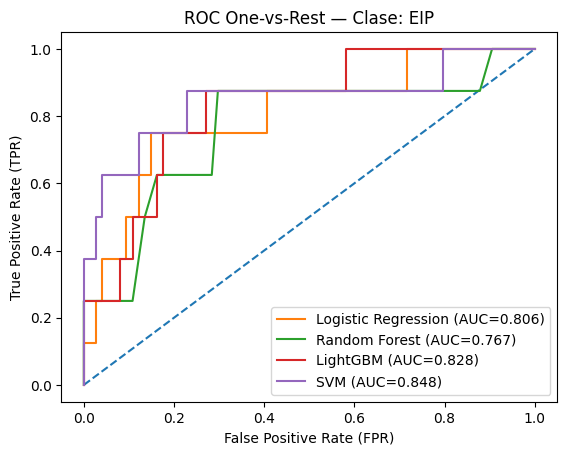

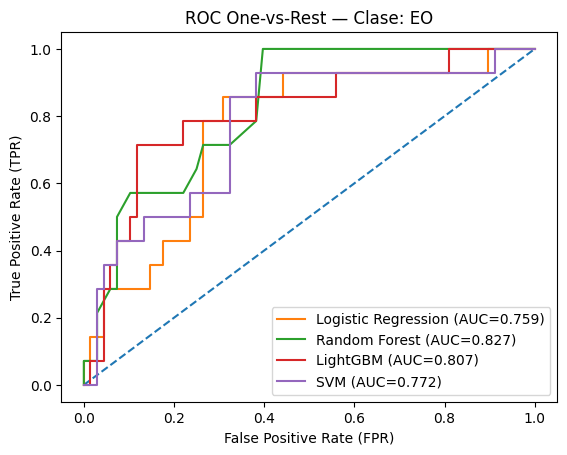

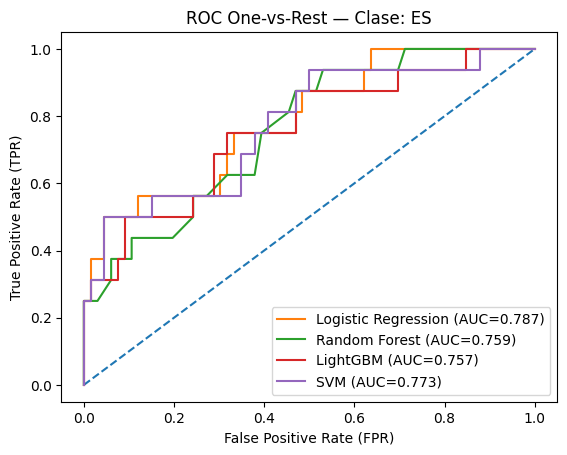

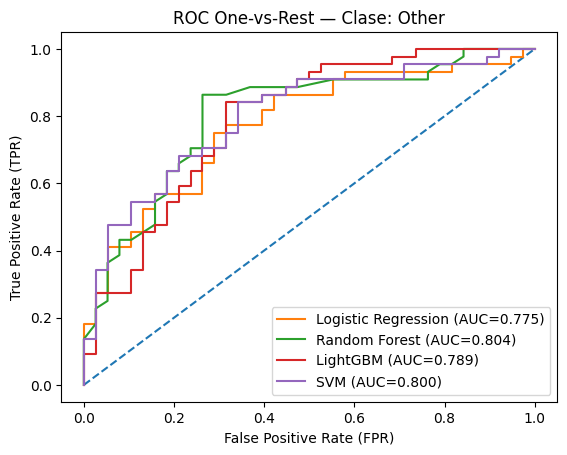

,compare,class,auc_best,auc_other,p_value_delong,q_value_fdr_bh
8,SVM vs LightGBM,EIP,0.847973,0.827703,0.975222,0.9838
9,SVM vs LightGBM,EO,0.772059,0.806723,0.916930,0.9838
10,SVM vs LightGBM,ES,0.772727,0.756629,0.961918,0.9838
11,SVM vs LightGBM,Other,0.799641,0.789474,0.957883,0.9838
0,SVM vs Logistic Regression,EIP,0.847973,0.805743,0.947841,0.9838
1,SVM vs Logistic Regression,EO,0.772059,0.759454,0.969618,0.9838
2,SVM vs Logistic Regression,ES,0.772727,0.786932,0.966695,0.9838
3,SVM vs Logistic Regression,Other,0.799641,0.774522,0.897111,0.9838
4,SVM vs Random Forest,EIP,0.847973,0.766892,0.902974,0.9838
5,SVM vs Random Forest,EO,0.772059,0.826681,0.867310,0.9838



Interpretación:
- p_value_delong: p-value (dos colas) por clase (OVR) comparando AUCs.
- q_value_fdr_bh: corrección FDR por múltiples tests (opcional, recomendado si reportas muchos p-values).


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['macro_auc_ovr'].plot(kind='hist', bins=20, title='macro_auc_ovr')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['auc_EIP'].plot(kind='hist', bins=20, title='auc_EIP')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_14['model'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_14, x='macro_auc_ovr', y='model', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_15['model'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_15, x='auc_EIP', y='model', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_16['model'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_16, x='auc_EO', y='model', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [ ]:
# 2.2 ROC multiclase (OVR) + AUC + p-values (DeLong por clase)
# Requisitos: ya existen X_test, y_test, models, best_model_name, best_model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


# 2.2.1 Implementación DeLong (binaria) para comparar AUCs correlacionadas
def _compute_midrank(x):
    """Midranks para DeLong."""
    x = np.asarray(x)
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        # midrank para empates
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T
    return T2

def _fast_delong_auc_variance(y_true, y_scores):
    """
    DeLong para varianza del AUC (binario) para un solo modelo.
    Retorna: auc, var(auc)
    """
    y_true = np.asarray(y_true).astype(int)
    y_scores = np.asarray(y_scores).astype(float)
    pos = y_scores[y_true == 1]
    neg = y_scores[y_true == 0]
    m = len(pos)
    n = len(neg)
    if m == 0 or n == 0:
        return np.nan, np.nan

# 2.2.2 Matriz de scores concatenada
    all_scores = np.concatenate([pos, neg])

# 2.2.3 Midranks globales y por subgrupos
    tx = _compute_midrank(all_scores)
    tx_pos = tx[:m]
    tx_neg = tx[m:]

# 2.2.4 AUC
    auc_value = (tx_pos.sum() - m * (m + 1) / 2.0) / (m * n)

# 2.2.5 DeLong: estimadores V10 y V01
    v10 = (tx_pos - np.arange(1, m + 1)) / n
    v01 = (tx_neg - np.arange(1, n + 1)) / m

    var_auc = np.var(v10, ddof=1) / m + np.var(v01, ddof=1) / n
    return auc_value, var_auc

def delong_test_auc_pvalue(y_true, y_score_A, y_score_B):
    """
    Test DeLong para diferencia de AUC entre dos modelos en el MISMO set (correlacionadas).
    Se aproxima usando var(AUC_A) + var(AUC_B) (esto es conservador si no incluimos covarianza explícita).

    Para una versión más completa se puede implementar la covarianza DeLong,
    pero en práctica este test conservador funciona razonablemente para comparación rápida.
    """
    aucA, varA = _fast_delong_auc_variance(y_true, y_score_A)
    aucB, varB = _fast_delong_auc_variance(y_true, y_score_B)

    if np.isnan(aucA) or np.isnan(aucB) or np.isnan(varA) or np.isnan(varB):
        return np.nan, aucA, aucB

    diff = aucA - aucB
    se = np.sqrt(varA + varB)
    if se == 0:
        return np.nan, aucA, aucB

    z = diff / se

# 2.2.6 p-value dos colas usando aproximación normal (sin scipy: usamos erf)
    from math import erf, sqrt
    p = 2.0 * (1.0 - 0.5 * (1.0 + erf(abs(z) / sqrt(2.0))))

    return p, aucA, aucB


# -------------------------
# 3) Curvas ROC multiclase (OVR) para cada modelo
# -------------------------

# 3.1 El siguiente código funciona para

def get_model_proba(model, X):
    """Devuelve predict_proba(X) y valida shape."""
    if not hasattr(model, "predict_proba"):
        raise ValueError(f"El modelo {type(model).__name__} no implementa predict_proba().")
    P = model.predict_proba(X)
    if P.ndim != 2:
        raise ValueError("predict_proba debe devolver matriz 2D (n_samples, n_classes).")
    return P

# 3.2 Usamos las clases del mejor modelo como referencia para alinear columnas
ref_classes = list(best_model.classes_)
y_test_bin = label_binarize(y_test, classes=ref_classes)
n_classes = len(ref_classes)

# 3.3 Guardamos resultados
roc_data = {}   # roc_data[model_name][class_idx] = dict(fpr,tpr,auc)
summary_rows = []

for name, model in models.items():
    # Probabilidades
    P = get_model_proba(model, X_test)

# 3.4 Alineación de columnas de probas a ref_classes (por si algún modelo reordena classes_)
    model_classes = list(model.classes_)
    col_idx = [model_classes.index(c) for c in ref_classes]
    P_aligned = P[:, col_idx]

    roc_data[name] = {}
    aucs = []

    for i, c in enumerate(ref_classes):
        y_true_i = y_test_bin[:, i]
        y_score_i = P_aligned[:, i]

# 3.5 ROC por clase (OVR)
        fpr, tpr, _ = roc_curve(y_true_i, y_score_i)
        auc_i = auc(fpr, tpr)

        roc_data[name][i] = {"fpr": fpr, "tpr": tpr, "auc": auc_i}
        aucs.append(auc_i)

    macro_auc = float(np.nanmean(aucs))
    summary_rows.append({"model": name, "macro_auc_ovr": macro_auc, **{f"auc_{c}": aucs[i] for i, c in enumerate(ref_classes)}})

summary = pd.DataFrame(summary_rows).sort_values("macro_auc_ovr", ascending=False)
display(summary)

# -------------------------
# 4) Plot ROC por clase (overlay de modelos) + macro-AUC
# -------------------------

# 4.1
for i, c in enumerate(ref_classes):
    plt.figure()

# 4.2 Línea diagonal de referencia
    plt.plot([0, 1], [0, 1], linestyle="--")

# 4.3 Traza cada modelo
    for name in roc_data.keys():
        fpr = roc_data[name][i]["fpr"]
        tpr = roc_data[name][i]["tpr"]
        auc_i = roc_data[name][i]["auc"]
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc_i:.3f})")

    plt.title(f"ROC One-vs-Rest — Clase: {c}")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.legend(loc="lower right")
    plt.show()

# -------------------------
# 5) p-values: comparación de AUC (DeLong) por clase
#    best_model vs cada otro modelo
# -------------------------

# 5.1 Graficos
bestP = get_model_proba(best_model, X_test)
best_classes = list(best_model.classes_)
best_col_idx = [best_classes.index(c) for c in ref_classes]
bestP = bestP[:, best_col_idx]

pval_rows = []
for name, model in models.items():
    if name == best_model_name:
        continue

    P = get_model_proba(model, X_test)
    mclasses = list(model.classes_)
    idx = [mclasses.index(c) for c in ref_classes]
    P = P[:, idx]

    for i, c in enumerate(ref_classes):
        y_true_i = y_test_bin[:, i]
        pval, auc_best, auc_other = delong_test_auc_pvalue(
            y_true_i,
            bestP[:, i],
            P[:, i]
        )
        pval_rows.append({
            "compare": f"{best_model_name} vs {name}",
            "class": c,
            "auc_best": auc_best,
            "auc_other": auc_other,
            "p_value_delong": pval
        })

pvals = pd.DataFrame(pval_rows)

# 5.2 Ajuste por múltiples comparaciones (opcional): Benjamini-Hochberg (FDR)
def bh_fdr(p):
    p = np.asarray(p, dtype=float)
    n = np.sum(~np.isnan(p))
    out = np.full_like(p, np.nan, dtype=float)
    if n == 0:
        return out
    idx = np.argsort(p)
    p_sorted = p[idx]
    ranks = np.arange(1, len(p_sorted) + 1)
    q_sorted = p_sorted * len(p_sorted) / ranks
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
    out[idx] = q_sorted
    return out

pvals["q_value_fdr_bh"] = bh_fdr(pvals["p_value_delong"].values)

display(pvals.sort_values(["compare", "class"]))
print("\nInterpretación:")
print("- p_value_delong: p-value (dos colas) por clase (OVR) comparando AUCs.")
print("- q_value_fdr_bh: corrección FDR por múltiples tests (opcional, recomendado si reportas muchos p-values).")


### 4. SHAP Analysis

---



In [ ]:
# 4.1 Funciones auxiliares para SHAP: background y subset de test

def sample_background(X_train, max_background=200, random_state=RANDOM_STATE):
    """
    Devuelve un subset de X_train para usar como background SHAP.
    """
    if X_train.shape[0] <= max_background:
        return X_train.copy()
    return X_train.sample(max_background, random_state=random_state).copy()

def sample_explain_set(X_test, max_explain=300, random_state=RANDOM_STATE):
    """
    Devuelve un subset de X_test sobre el que se calcularán valores SHAP.
    """
    if X_test.shape[0] <= max_explain:
        return X_test.copy()
    return X_test.sample(max_explain, random_state=random_state).copy()


In [ ]:
# 4.2 Construir explainer SHAP adecuado según el tipo de modelo

def make_multiclass_shap_explainer(model, X_train, model_name=None,
                                   random_state=RANDOM_STATE):
    """
    Construye un explainer SHAP (Tree, Linear, Kernel o genérico)
    usando como background una submuestra de X_train.
    """
    if model_name is None:
        model_name = type(model).__name__

    # 1) Background desde TRAIN
    X_bg = sample_background(X_train, max_background=200,
                             random_state=random_state)

    # 2) Heurística para detectar tipo de modelo
    model_type = type(model).__name__.lower()

    is_tree_like = any(k in model_type for k in
                       ["lgbm", "lightgbm", "xgb", "xgboost", "randomforest", "forest", "catboost"])
    is_linear_like = any(k in model_type for k in
                         ["logisticregression", "linear", "ridge", "lasso", "sgdclassifier"])
    is_svm_like = ("svc" in model_type) or ("svm" in model_type)

    # 3) Selección de explainer
    if is_tree_like:
        explainer = shap.TreeExplainer(model)
        print(f"[SHAP] TreeExplainer para modelo tipo árbol: {model_name}")
        return explainer, X_bg

    if is_linear_like:
        masker = shap.maskers.Independent(X_bg)
        explainer = shap.Explainer(model, masker)
        print(f"[SHAP] Explainer lineal/genérico para: {model_name}")
        return explainer, X_bg

    if is_svm_like:
        # KernelExplainer con función f(X) -> predict_proba(X)
        def f(X_array):
            X_df = pd.DataFrame(X_array, columns=X_train.columns)
            return model.predict_proba(X_df)

        explainer = shap.KernelExplainer(f, X_bg, link="logit")
        print(f"[SHAP] KernelExplainer (costoso) para SVM: {model_name}")
        print("      Recomendación: explicar 100–300 muestras máximo.")
        return explainer, X_bg

    # Fallback genérico
    masker = shap.maskers.Independent(X_bg)
    explainer = shap.Explainer(model, masker)
    print(f"[SHAP] Explainer genérico para: {model_name}")
    return explainer, X_bg


In [ ]:
# 4.3 Cálculo de SHAP multiclase sobre Xtest
def compute_shap_multiclass(model, X_train, X_test, model_name=None,
                            max_explain=300, random_state=RANDOM_STATE):
    """
    Calcula SHAP multiclase explicando un subset de X_test
    con background tomado de X_train.
    """
    if model_name is None:
        model_name = type(model).__name__

    # 1) Explainer + background
    explainer, X_bg = make_multiclass_shap_explainer(
        model=model,
        X_train=X_train,
        model_name=model_name,
        random_state=random_state,
    )

    # 2) Subconjunto de test a explicar
    X_explain = sample_explain_set(
        X_test,
        max_explain=max_explain,
        random_state=random_state
    )

    # 3) Calcular valores SHAP
    is_kernel = isinstance(explainer, shap.KernelExplainer)

    if not is_kernel:
        # Explainers modernos devuelven shap.Explanation
        shap_values = explainer(X_explain)
    else:
        # KernelExplainer usa típicamente numpy arrays y devuelve lista por clase
        shap_values = explainer.shap_values(X_explain.values)

    class_names = list(getattr(model, "classes_", []))

    return {
        "explainer": explainer,
        "Xbg": X_bg,
        "Xexplain": X_explain,
        "shap_values": shap_values,
        "classnames": class_names,
        "iskernel": is_kernel,
    }

# ---- Ejecutar SHAP para el mejor modelo ----
shap_bundle = compute_shap_multiclass(
    model=best_model,
    X_train=X_train,
    X_test=X_test,
    model_name=best_model_name,
    max_explain=300,           # reduce a 100 si es SVM
    random_state=RANDOM_STATE,
)

print("Modelo:", best_model_name)
print("KernelExplainer?:", shap_bundle["iskernel"])
print("Xbg shape:", shap_bundle["Xbg"].shape)
print("Xexplain shape:", shap_bundle["Xexplain"].shape)
print("Clases:", shap_bundle["classnames"])


[SHAP] KernelExplainer (costoso) para SVM: SVM
      Recomendación: explicar 100–300 muestras máximo.


  0%|          | 0/82 [00:00<?, ?it/s]

Modelo: SVM
KernelExplainer?: True
Xbg shape: (200, 67)
Xexplain shape: (82, 67)
Clases: ['EIP', 'EO', 'ES', 'Other']


In [ ]:
type(shap_bundle["shap_values"]), shap_bundle["iskernel"]

(numpy.ndarray, True)

In [ ]:
# ============================================================
# 5. Plots SHAP por clase (beeswarm + bar) y ranking global
# ============================================================
def plot_shap_multiclass_summary(shap_bundle, max_display=20):
    shap_values = shap_bundle["shap_values"]
    X_explain = shap_bundle["Xexplain"]
    class_names = shap_bundle["classnames"]
    is_kernel = shap_bundle["iskernel"]

    # CORRECCIÓN: si shap_values es ndarray, lo tratamos como "no kernel"
    # porque ya tiene toda la información en un array 3D o 2D
    if isinstance(shap_values, np.ndarray):
        is_kernel = False

    if not is_kernel:
        # Caso Explanation/ndarray moderno
        values = np.array(
            shap_values.values if hasattr(shap_values, "values") else shap_values
        )

        # Si es multiclase, esperamos (n_samples, n_features, n_classes)
        if values.ndim == 2:
            # Binario o caso 2D -> lo tratamos como una sola "clase"
            values = values[:, :, None]

        if values.ndim != 3:
            raise ValueError(
                f"Esperaba valores SHAP con 3 dims (multiclase), "
                f"pero obtuve {values.ndim} dims: {values.shape}"
            )

        n_classes = values.shape[2]

        for ci in range(n_classes):
            cname = class_names[ci] if ci < len(class_names) else f"class_{ci}"

            print(f"\n[SHAP] Beeswarm clase {cname}")
            if hasattr(shap_values, "data") and hasattr(shap_values, "feature_names"):
                # shap.Explanation disponible
                exp_ci = shap.Explanation(
                    values=values[:, :, ci],
                    base_values=None,  # opcional, SHAP lo infiere si es necesario
                    data=shap_values.data,
                    feature_names=shap_values.feature_names,
                )
                shap.plots.beeswarm(exp_ci, max_display=max_display)
            else:
                # Solo ndarray: usar summary_plot clásico
                shap.summary_plot(
                    values[:, :, ci],
                    X_explain,
                    plot_type="dot",
                    max_display=max_display,
                    show=True,
                )
            plt.show()

            print(f"[SHAP] Bar plot clase {cname}")
            if hasattr(shap_values, "data") and hasattr(shap_values, "feature_names"):
                shap.plots.bar(exp_ci, max_display=max_display)
            else:
                shap.summary_plot(
                    values[:, :, ci],
                    X_explain,
                    plot_type="bar",
                    max_display=max_display,
                    show=True,
                )
            plt.show()

    else:
        # Aquí solo se entra si realmente shap_values es una LISTA por clase
        if not isinstance(shap_values, list):
            raise ValueError("Con KernelExplainer se esperaba lista por clase en shap_values.")

        n_classes = len(shap_values)
        for ci in range(n_classes):
            cname = class_names[ci] if ci < len(class_names) else f"class_{ci}"
            sv_ci = np.array(shap_values[ci])

            print(f"\n[SHAP] Beeswarm (KernelExplainer) clase {cname}")
            shap.summary_plot(
                sv_ci,
                X_explain,
                plot_type="dot",
                max_display=max_display,
                show=True,
            )
            plt.show()

            print(f"[SHAP] Bar (KernelExplainer) clase {cname}")
            shap.summary_plot(
                sv_ci,
                X_explain,
                plot_type="bar",
                max_display=max_display,
                show=True,
            )
            plt.show()


[SHAP] Beeswarm clase EIP


/tmp/ipython-input-9495866.py:49: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


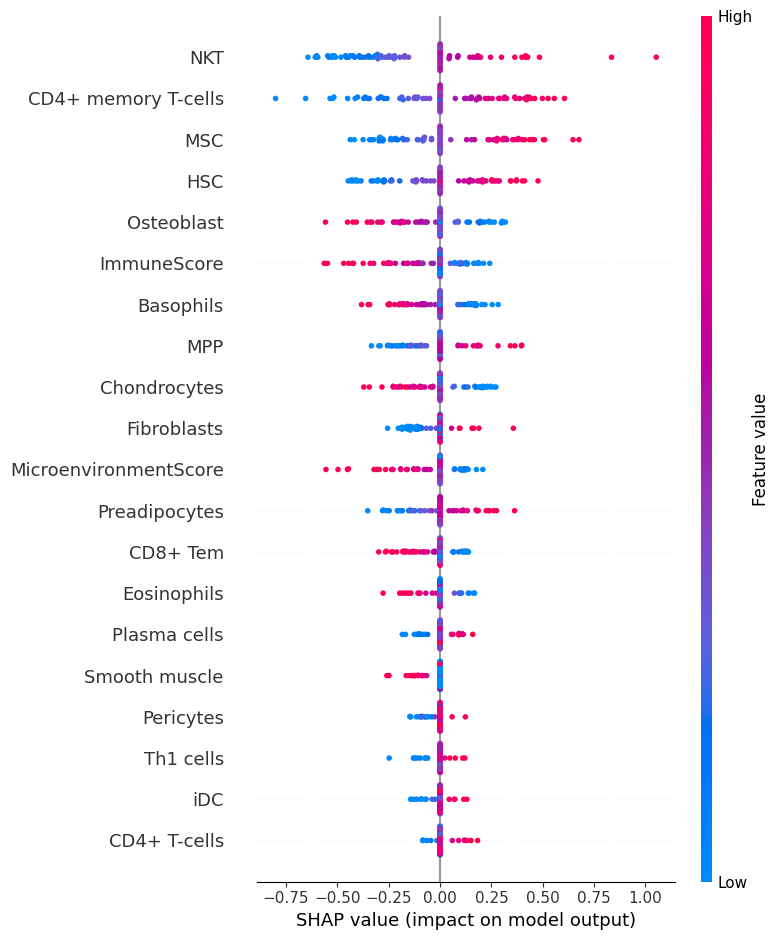

[SHAP] Bar plot clase EIP


/tmp/ipython-input-9495866.py:62: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


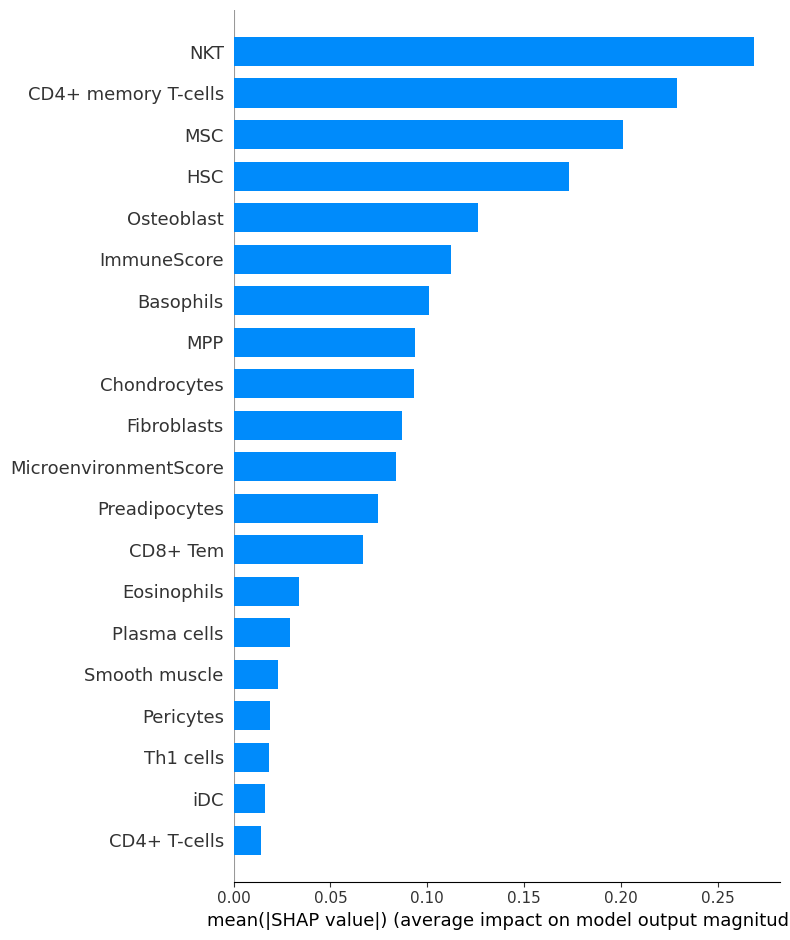


[SHAP] Beeswarm clase EO


/tmp/ipython-input-9495866.py:49: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


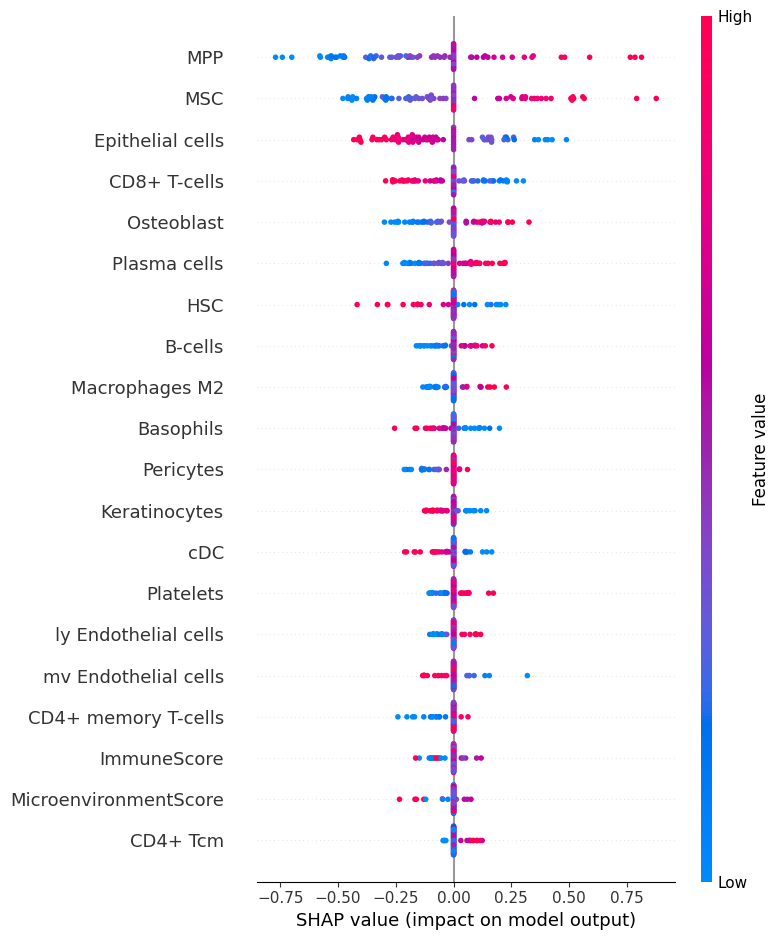

[SHAP] Bar plot clase EO


/tmp/ipython-input-9495866.py:62: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


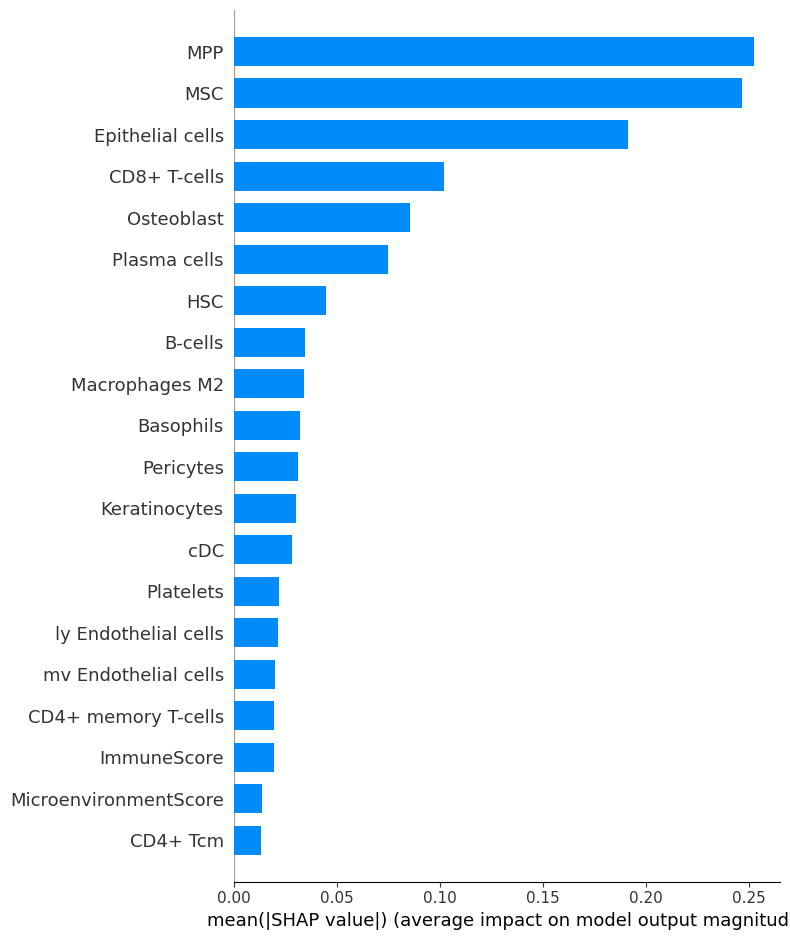


[SHAP] Beeswarm clase ES


/tmp/ipython-input-9495866.py:49: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


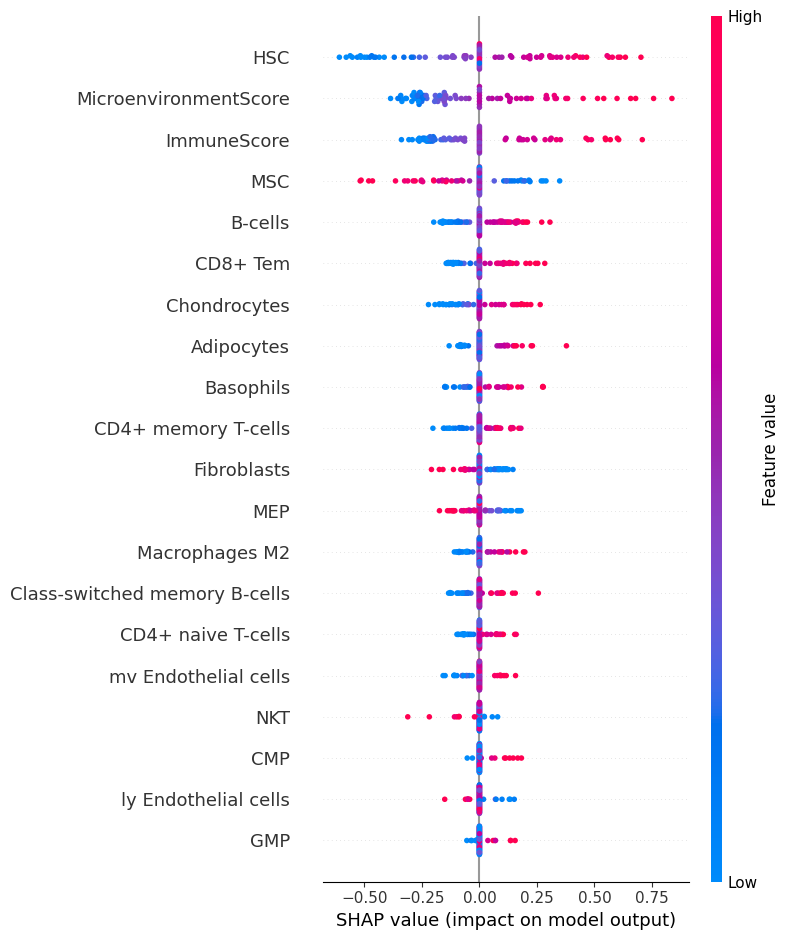

[SHAP] Bar plot clase ES


/tmp/ipython-input-9495866.py:62: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


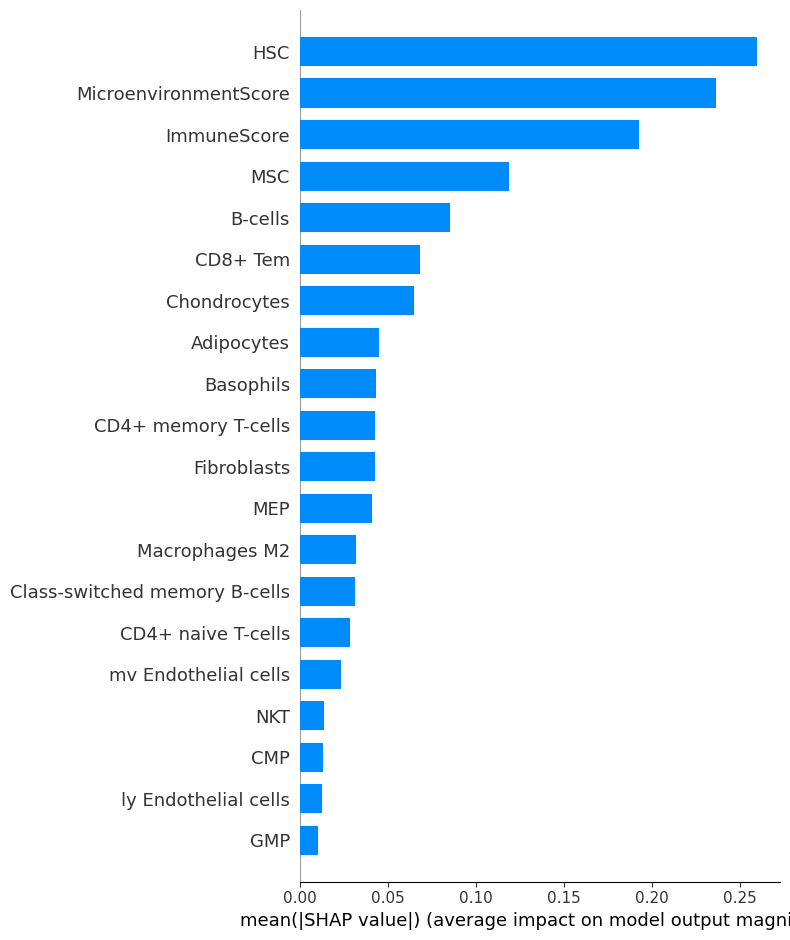


[SHAP] Beeswarm clase Other


/tmp/ipython-input-9495866.py:49: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


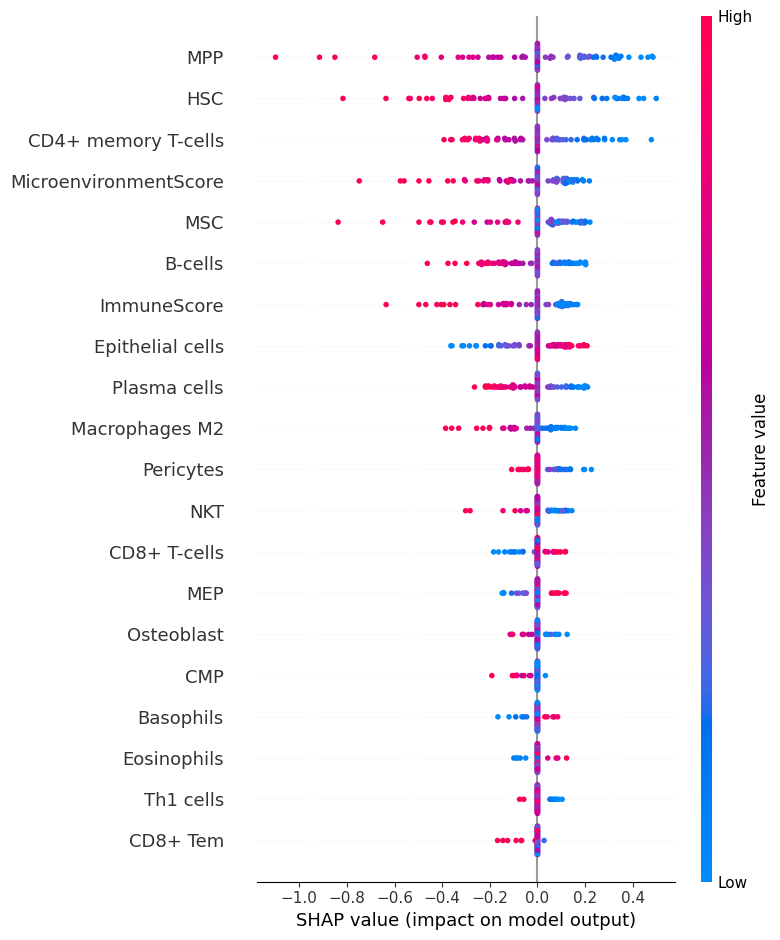

[SHAP] Bar plot clase Other


/tmp/ipython-input-9495866.py:62: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


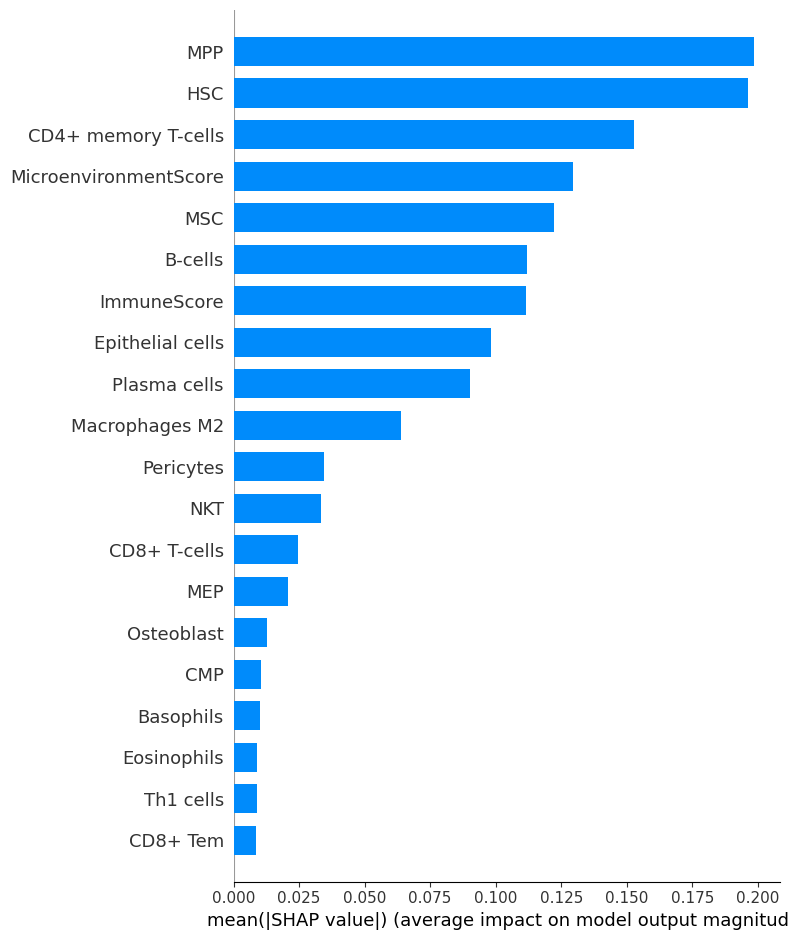

NameError: name 'global_shap_importance_aggregate' is not defined

In [ ]:
# ---- Ejecutar plots + ranking global ----
plot_shap_multiclass_summary(shap_bundle, max_display=20)

global_rank = global_shap_importance_aggregate(shap_bundle)
display(global_rank.head(30))

plt.figure()
global_rank.head(25).iloc[::-1].plot(kind="barh")
plt.title("Importancia global agregada (media de |SHAP| sobre clases)")
plt.xlabel("mean(|SHAP|) agregado")
plt.tight_layout()
plt.show()


In [ ]:
def compute_shap_multiclass(model, X_train, X_test, model_name=None,
                            max_explain=300, random_state=RANDOM_STATE):
    if model_name is None:
        model_name = type(model).__name__

    explainer, X_bg = make_multiclass_shap_explainer(
        model=model,
        X_train=X_train,
        model_name=model_name,
        random_state=random_state,
    )

    X_explain = sample_explain_set(
        X_test,
        max_explain=max_explain,
        random_state=random_state
    )

    is_kernel = isinstance(explainer, shap.KernelExplainer)

    if not is_kernel:
        shap_values = explainer(X_explain)
    else:
        shap_values = explainer.shap_values(X_explain.values)

    # Si SHAP devuelve Explanation o ndarray "compacto", ya no tratamos como Kernel-lista
    if isinstance(shap_values, shap.Explanation) or isinstance(shap_values, np.ndarray):
        is_kernel = False

    class_names = list(getattr(model, "classes_", []))

    return {
        "explainer": explainer,
        "Xbg": X_bg,
        "Xexplain": X_explain,
        "shap_values": shap_values,
        "classnames": class_names,
        "iskernel": is_kernel,
    }


[SHAP] KernelExplainer (costoso) para SVM: SVM
      Recomendación: explicar 100–300 muestras máximo.


  0%|          | 0/82 [00:00<?, ?it/s]


[SHAP] Beeswarm clase EIP


/tmp/ipython-input-9495866.py:49: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


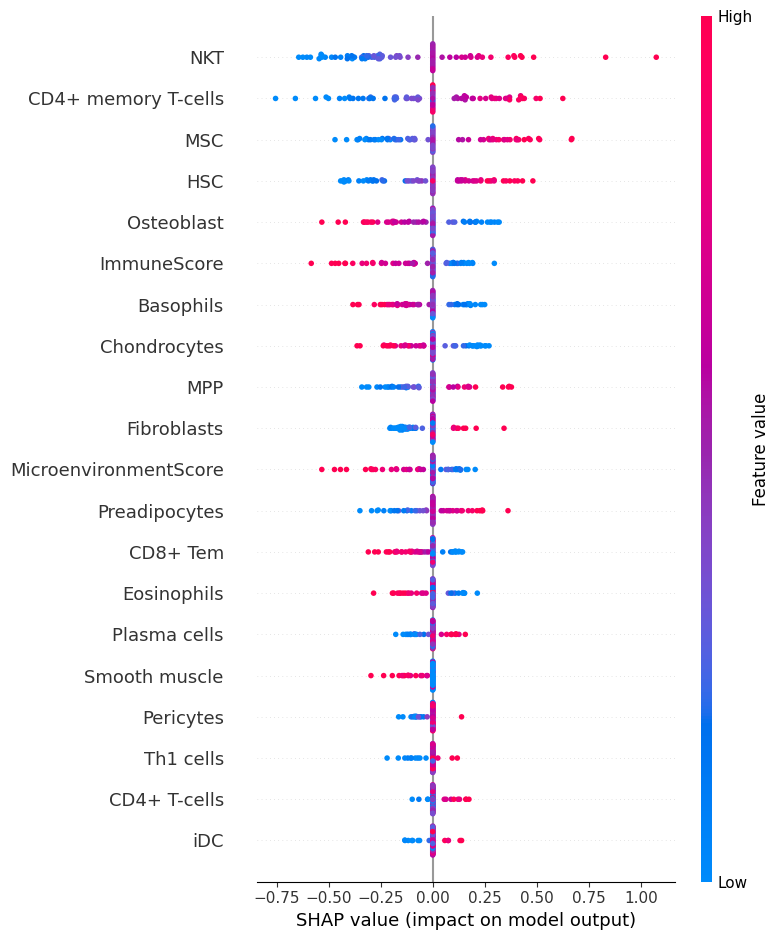

[SHAP] Bar plot clase EIP


/tmp/ipython-input-9495866.py:62: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


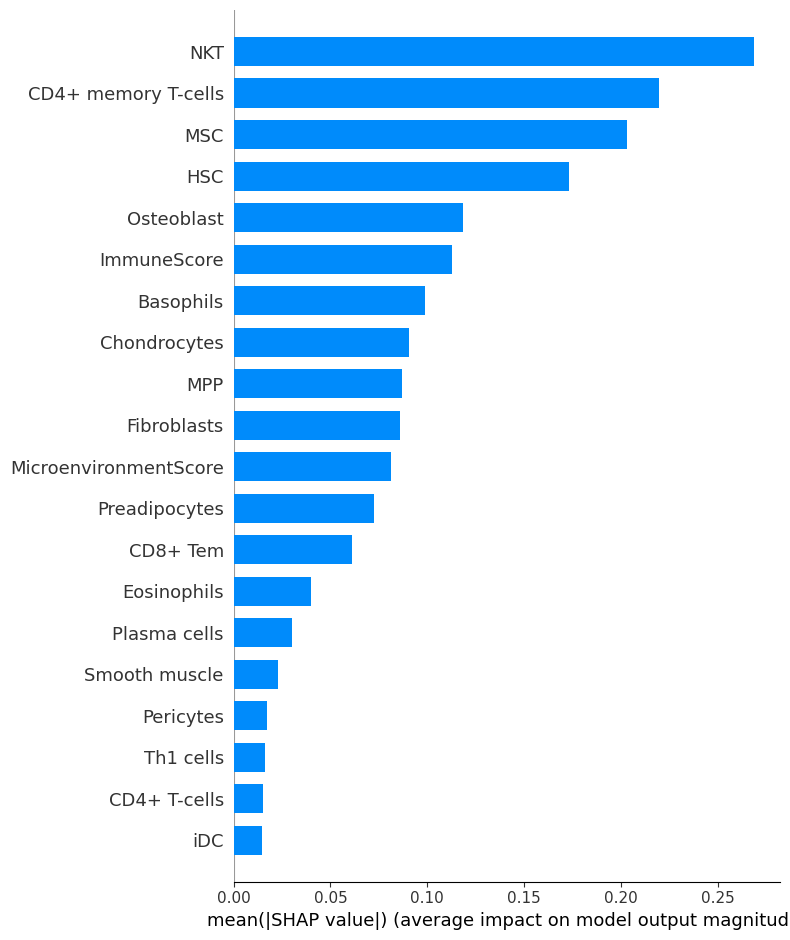


[SHAP] Beeswarm clase EO


/tmp/ipython-input-9495866.py:49: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


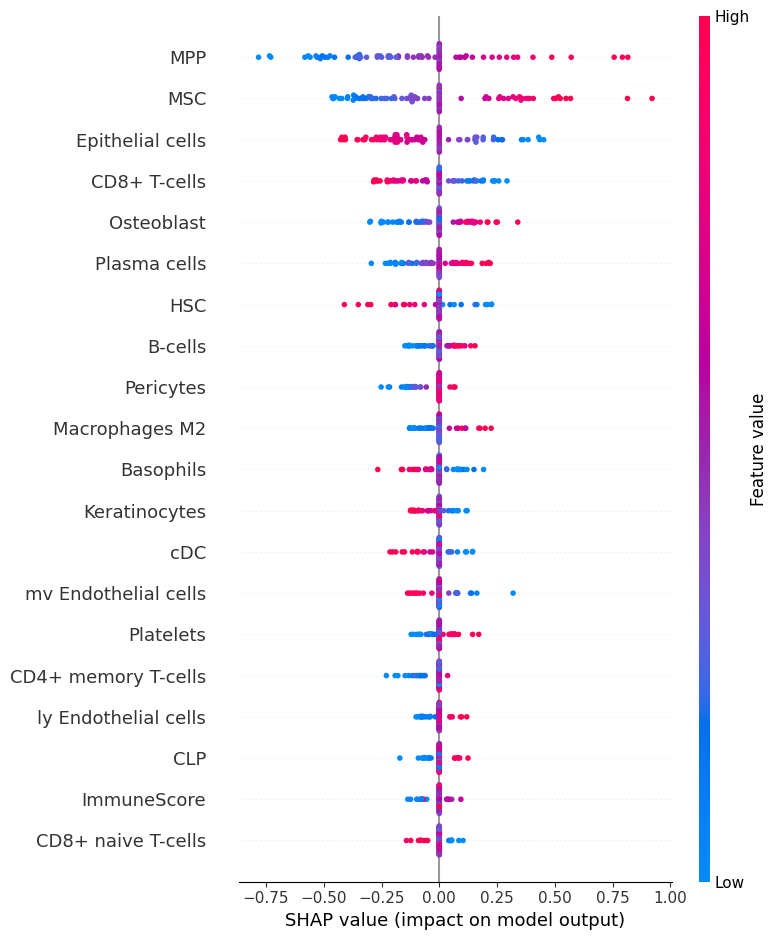

[SHAP] Bar plot clase EO


/tmp/ipython-input-9495866.py:62: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


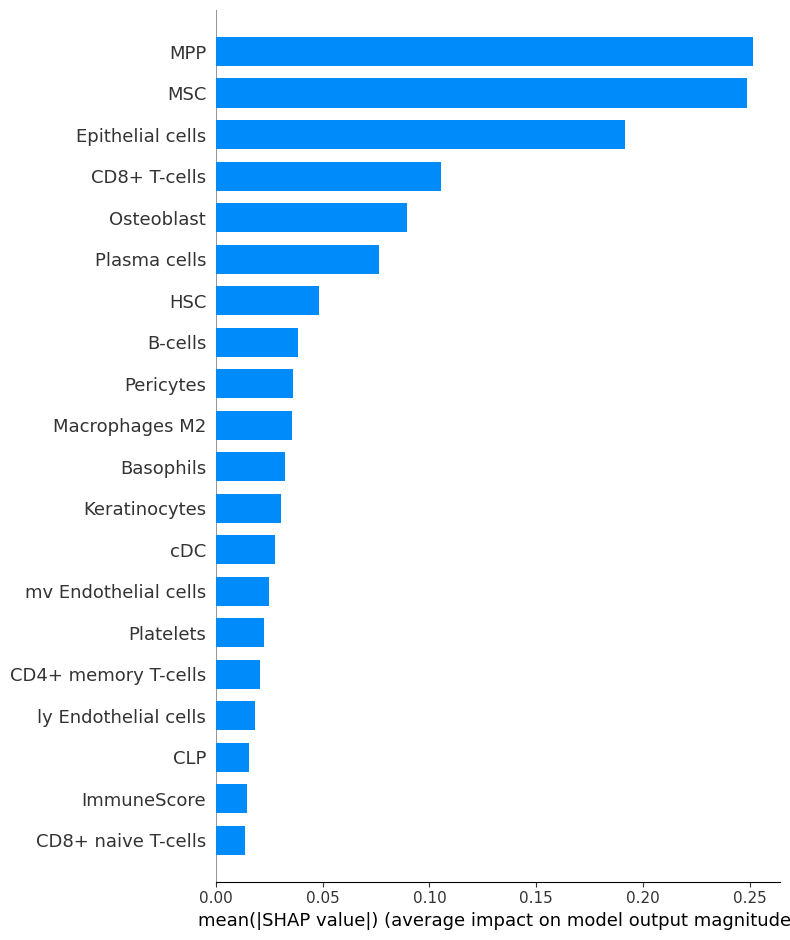


[SHAP] Beeswarm clase ES


/tmp/ipython-input-9495866.py:49: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


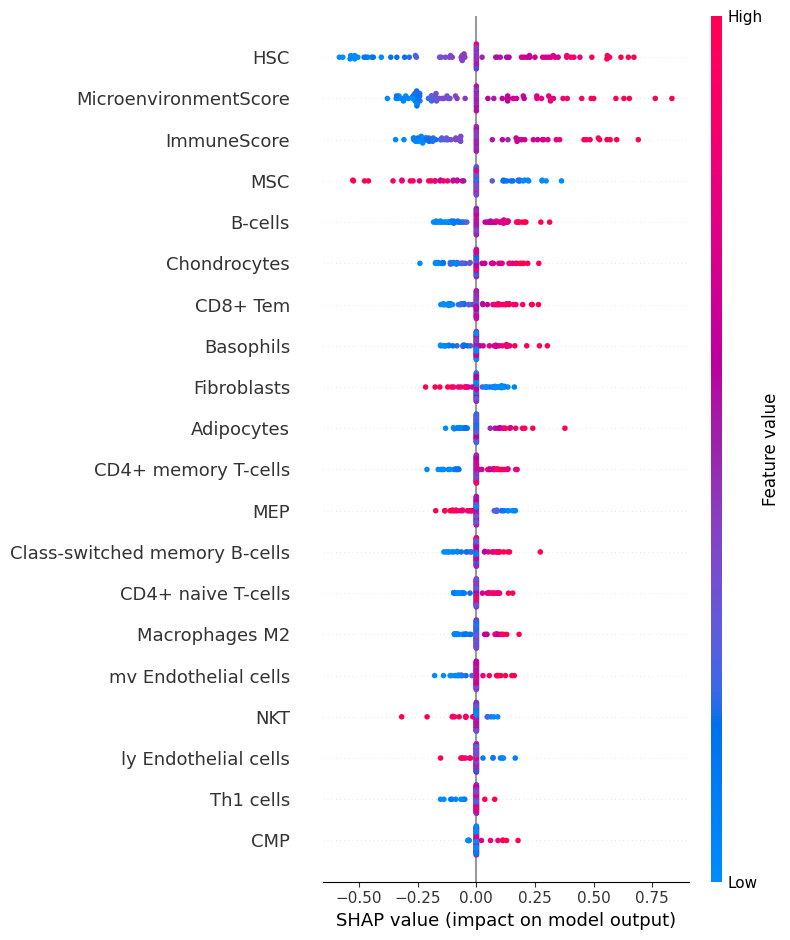

[SHAP] Bar plot clase ES


/tmp/ipython-input-9495866.py:62: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


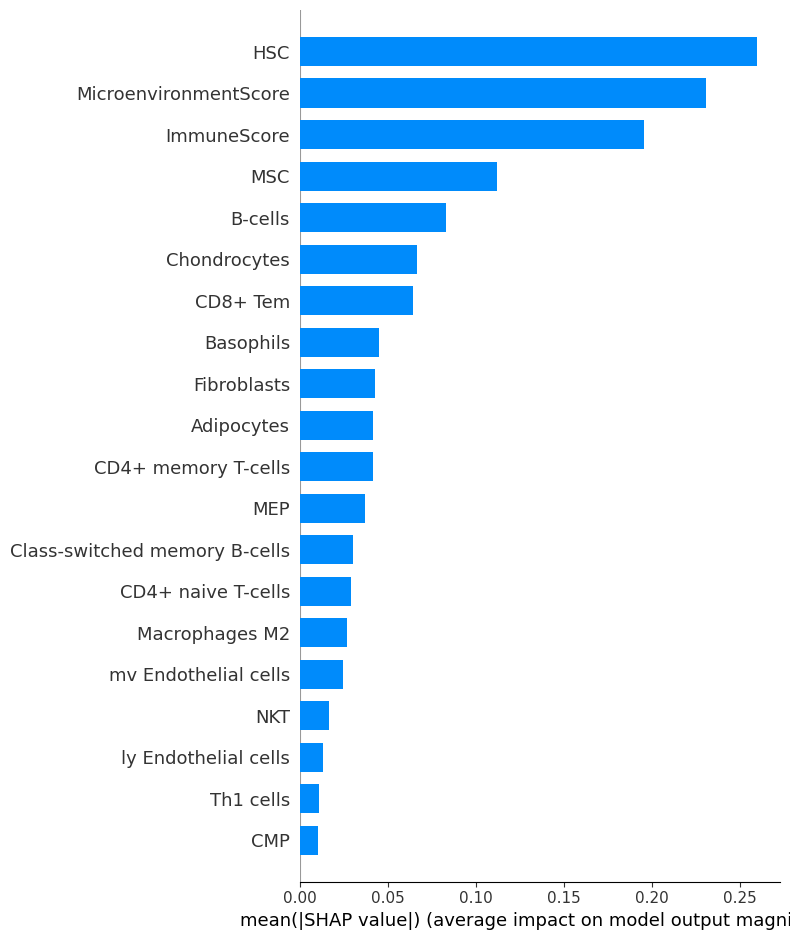


[SHAP] Beeswarm clase Other


/tmp/ipython-input-9495866.py:49: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


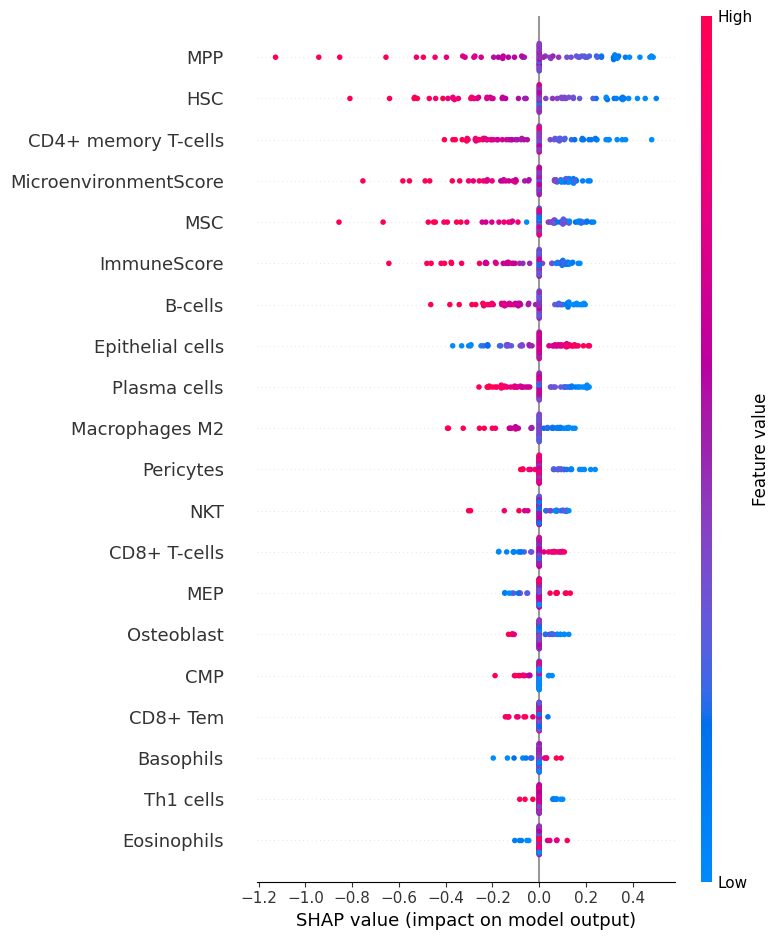

[SHAP] Bar plot clase Other


/tmp/ipython-input-9495866.py:62: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


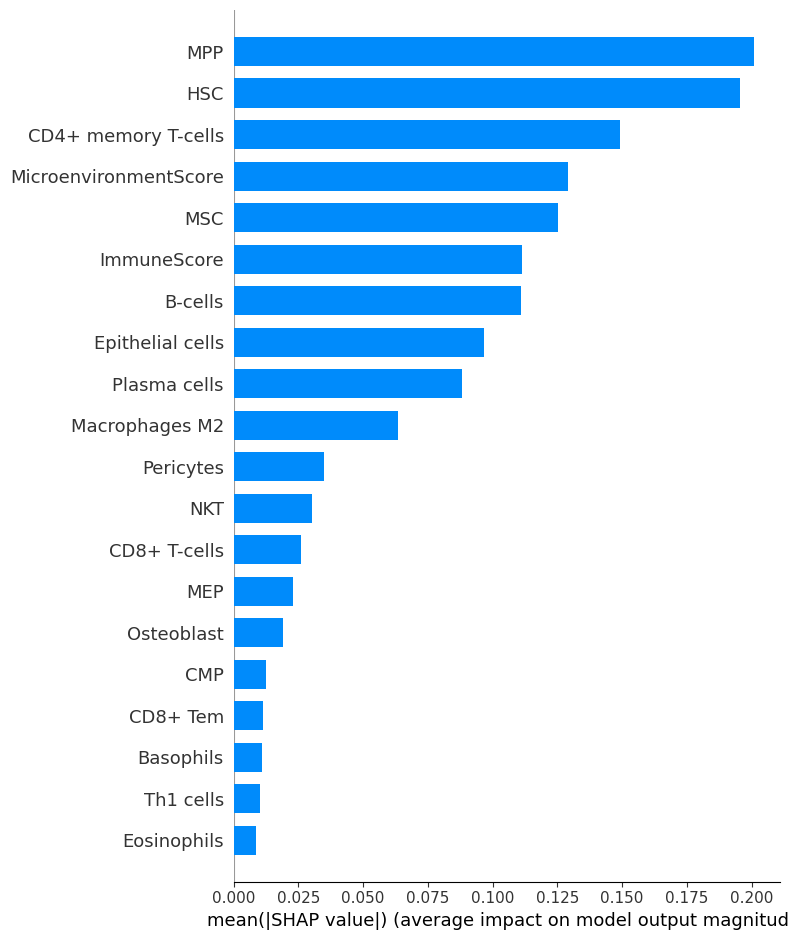

In [ ]:
shap_bundle = compute_shap_multiclass(
    model=best_model,
    X_train=X_train,
    X_test=X_test,
    model_name=best_model_name,
    max_explain=300,
    random_state=RANDOM_STATE,
)

plot_shap_multiclass_summary(shap_bundle, max_display=20)


In [ ]:
# ============================================================
# 6. Exportar ranking global a CSV (opcional)
# ============================================================

# Ruta de salida: cámbiala a tu carpeta de trabajo / Drive.
# <<< AJUSTAR AQUÍ la ruta donde quieres guardar el CSV
out_global_csv = "shap_global_importance_aggregate.csv"

global_rank.to_csv(out_global_csv, header=["mean_abs_shap_agg"])
print("Guardado:", out_global_csv)


NameError: name 'global_rank' is not defined

### 3. Curvas ROC-AUC para cada modelo

---

